In [1]:
import pickle as pkl
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
from scipy.optimize import curve_fit
# import pylandau as pland
# import ROOT
import scipy.ndimage as ndimage
import numpy.ma as ma
from ROOT import TF1, TGraph, TLegend, TFile, TTree
import sys
import os

## ===== Así se importan las funciones de arhcivos en otras direcciones === ###
module_path = os.path.abspath('../.') # Adjust relative path as needed
# Or use an absolute path: module_path = '/home/your_user/projects/utils'

if module_path not in sys.path:
    sys.path.append(module_path)

from functions_MuonsNSAMP1 import * 

def gaussian(x, a, mean, sigma, y_move):
    return a * np.exp(-((x - mean)**2 / (2 * sigma**2))) - y_move

def diffution_curve(z, alpha, beta):
    return np.sqrt(np.abs(alpha * np.log(1 - (beta * z))))

In [2]:
import matplotlib.colors


plt.rcParams.update({
    "image.origin": "lower",
    "image.aspect": 1,
    #"text.usetex": True,
    "grid.alpha": .5,
    "axes.linewidth":2,
    "lines.linewidth" : 1,
    "font.size":    15.0,
    "xaxis.labellocation": 'right',  # alignment of the xaxis label: {left, right, center}
    "yaxis.labellocation": 'top',  # alignment of the yaxis label: {bottom, top, center}
    "xtick.top":           True ,  # draw ticks on the top side
    "xtick.major.size":    8    ,# major tick size in points
    "xtick.minor.size":    4      ,# minor tick size in points
    "xtick.direction":     'in',
    "xtick.minor.visible": True,
    "ytick.right":           True ,  # draw ticks on the top side
    "ytick.major.size":    8    ,# major tick size in points
    "ytick.minor.size":    4      ,# minor tick size in points
    "ytick.direction":     'in',
    "ytick.minor.visible": True,
    "ytick.major.width":   2   , # major tick width in points
    "ytick.minor.width":   1 ,
    "xtick.major.width":   2   , # major tick width in points
    "xtick.minor.width":   1 ,
    "legend.framealpha": 0 ,
    "legend.loc": 'best',

})

ColorMap = 'jet'
Norm = matplotlib.colors.LogNorm(vmin=10**-1, vmax=5 * 10**0)

In [3]:
# path = './Diccionarios_Espetro_Muones/dict_straight_muons_Extensions_1_to_4_Imgs_189_Elip_0.9_Sol_0.65_Skirts_0_NSIGMAS_13_KeV__NSAMP324.pkl'
# path = './Diccionarios_Espetro_Muones/dict_straight_muons_Extensions_1_to_4_Imgs_189_Elip_0.9_Sol_0.65_Skirts_0_NSIGMAS_20_KeV__NSAMP324.pkl'
path = '../Diccionarios_Espetro_Muones/dict_muons_NSAMP324_Extensions_1_2_4_NIMGS_393_SOL_0.65_ELIP_0.65_NSIGMAS_13_DEDL_1400_SIZE_250x539_KeV_n.pkl'

histogram = open(path, 'rb')
data_histogram = pkl.load(histogram)
histogram.close()

#### Visualizar las keys del diccionario ####
print('Las unidades de los datos están en: ', data_histogram['Energy_Units'])
print('Llaves principales del diccionario: ', data_histogram.keys())
print('Llaves secuandarias por extensión: ', data_histogram['extension_1'].keys(), end='\n\n')
Ext = 1

n_muons = data_histogram['All_Muons_Detected']
print('Se detectaron ', n_muons, ' muones (contando las 3 extensiones)')
DF_muons, list_datamask = DataFrame_muons(data_histogram, extension=Ext)

Las unidades de los datos están en:  2
Llaves principales del diccionario:  dict_keys(['Num_Images', 'All_Muons_Detected', 'Energy_Units', 'Elipticity', 'Solidity', 'Fit_errors', 'extension_1', 'extension_2', 'extension_4'])
Llaves secuandarias por extensión:  dict_keys(['charge', 'deltaEL', 'deltaL', 'all_events', 'theta', 'phi', 'gain', 'elip', 'sol', 'all_events_elip', 'all_events_sol', 'datamasked', 'run'])

Se detectaron  2833  muones (contando las 3 extensiones)


# Extension 1

### Muones verticales

#### DataFrame y visualización

In [4]:
### Se crea el dataframe y se selecciona un rango de datos ###
Ext = 1
DF_muons, list_datamask = DataFrame_muons(data_histogram, extension=Ext, units=1)
# display(DF_muons[450:500])
list_newmatrix = []
list_indexs =[]
# range_in_phi = DF_muons[DF_muons['Phi (Deg)'].between(85, 95)] # Verticales arriba
range_in_phi = DF_muons[DF_muons['Phi (Deg)'].between(265, 275)] # Verticales abajo

for index in range_in_phi.index:
    # print(index)
    list_newmatrix.append(list_datamask[index])
    list_indexs.append(index)

print(list_indexs)
list_phi_ext1 = data_histogram['extension_' + str(Ext)]['phi']
list_mask_rot = []

list_listsnxny = []

for index in list_indexs[:]:
    datamask = list_datamask[index]
    ylen, xlen = datamask.shape
    list_nxny = []

    data_mask_zeros = np.empty((ylen + 90, xlen+50))
    data_mask_zeros[:] = 0
    ylen_zeros, xlen_zeros = data_mask_zeros.shape
    # print(data_mask_zeros.shape)
    
    ### Angle rot ##
    # phi_rot = np.pi/2 - list_phi_ext1[index]
    phi_rot = 0
    # print(phi_rot, phi_rot + list_phi_ext1[index])

    # print('shape original: ', xlen, ylen)
    # print('shape zeros: ', xlen_zeros, ylen_zeros)

    for y_bin in range(0, ylen):
        for x_bin in range(0, xlen):
            if datamask[y_bin][x_bin] != 0:
                nx, ny = pixel_rot(x_bin=x_bin, x0=0, y_bin=y_bin, y0=0, theta= phi_rot)
                list_nxny.append((nx + 10, ny))
                # print(nx, ny)
                data_mask_zeros[ny][nx+10] = datamask[y_bin][x_bin]

    list_listsnxny.append(list_nxny)
    label_img, nlabels_img = sk.measure.label(data_mask_zeros > 0, connectivity=2, return_num=True)
    loc = nd.find_objects(label_img == 1)[0]
    mask_rot = np.invert(label_img==1)
    # data_mask_rot = ma.masked_array(data_mask_zeros, mask_rot)
    data_mask_rot = ma.masked_array(data_mask_zeros[loc[0].start:loc[0].stop, loc[1].start:loc[1].stop], mask_rot[loc[0].start:loc[0].stop, loc[1].start:loc[1].stop])

    list_mask_rot.append(data_mask_rot)
    # print('Shape rot: ', data_mask_rot.shape[1], data_mask_rot.shape[0])
    
    # plt.imshow(data_mask_rot)
    # plt.show()

# print(list_mask_rot)
#     

[58, 91, 114, 119, 121, 128, 143, 168, 173, 192, 253, 277, 288, 302, 306, 309, 321, 349, 362, 383, 385, 391, 404, 434, 451, 468, 516, 550, 588, 690, 793, 831, 864, 929, 1090, 1091]


,date_run,Gain (ADU/e-),Solidity,Elipticity,Theta (Deg),Phi (Deg),Charge (e-),l (cm),dEdL (KeV/cm)
Muon ID,,,,,,,,,
119,ENE2024,209.00097,0.730703,0.902299,56.034395,274.008303,8547.64192,0.129767,2423.991063


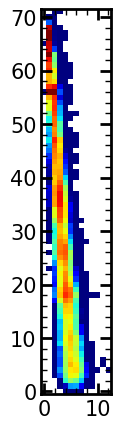

In [5]:
n_label = 119
display(DF_muons.iloc[[n_label]])

figure , axs = plt.subplots(1,1,figsize=[5,5])
# axs.imshow(list_mask_rot[n_label],  cmap = ColorMap, norm=Norm)  # 77, 1911, 2381, 2930 indices para path con elip 0.85, Sol 0.7
axs.imshow(list_datamask[n_label],  cmap = ColorMap, norm=Norm)  # 77, 1911, 2381, 2930 indices para path con elip 0.85, Sol 0.7
plt.show()


Numper of rows:  72
Long of line:  8


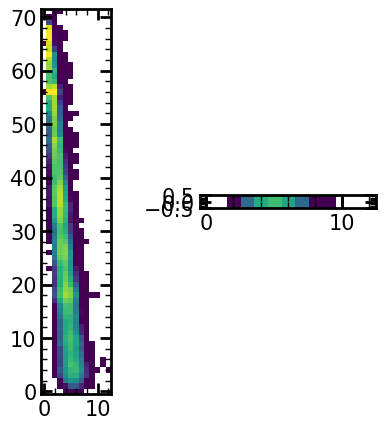

In [6]:
figure , axs = plt.subplots(1,2,figsize=[5,5])

label_muon = n_label
label_line = 10
muon = list_datamask[label_muon]
print('Numper of rows: ', muon.shape[0])
line = list_datamask[label_muon][label_line - 1:label_line][0]

n_longline = 0
for pixel in line:
    if pixel != 0:
        # print(pixel)
        n_longline += 1

print('Long of line: ', n_longline)

axs[0].imshow(list_datamask[label_muon], norm = Norm)
axs[1].imshow(list_datamask[label_muon][label_line - 1:label_line], norm = Norm)
plt.show()

In [7]:
list_index_long_muons = []
extension = 1

for index in range(0, len(list_newmatrix)):
    size_x = list_newmatrix[index].shape[1]
    size_y = list_newmatrix[index].shape[0]
    if size_y > 10:
    # if size_y > 50:
        # print(size_x, size_y)
        list_index_long_muons.append(list_indexs[index])

# print(list_index_long_muons)+
print('Muones largos detectados: ', len(list_index_long_muons))
print('Indices: ', list_index_long_muons)

Muones largos detectados:  36
Indices:  [58, 91, 114, 119, 121, 128, 143, 168, 173, 192, 253, 277, 288, 302, 306, 309, 321, 349, 362, 383, 385, 391, 404, 434, 451, 468, 516, 550, 588, 690, 793, 831, 864, 929, 1090, 1091]


#### Perfil Energético

56.03439509899177
Number of rows:  72


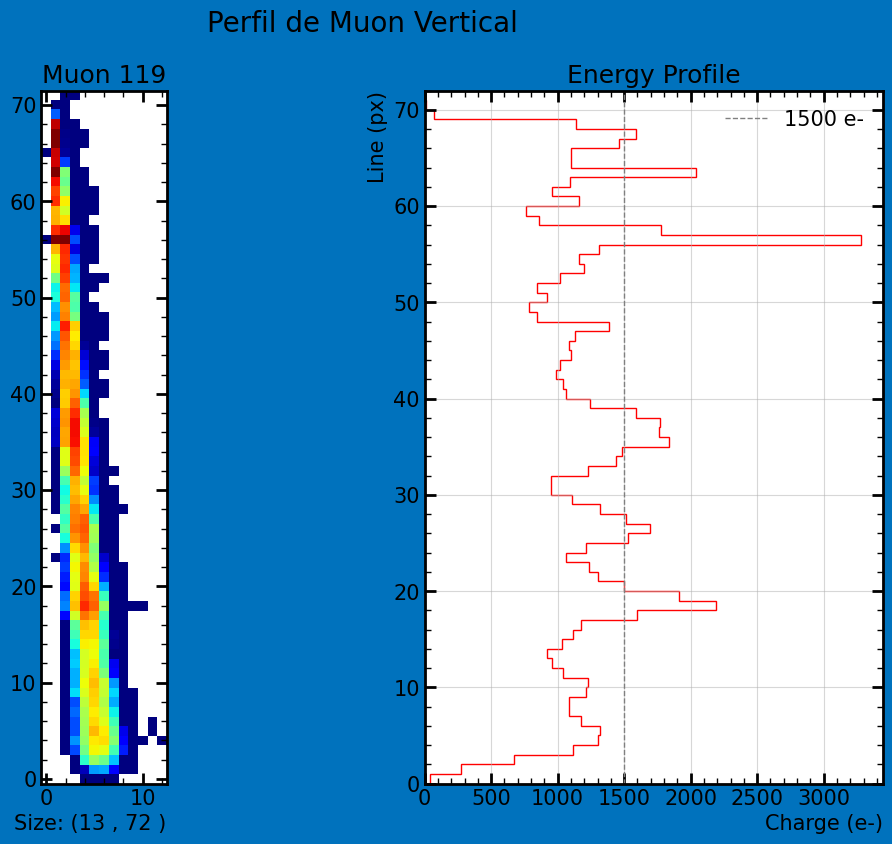

In [9]:
# [353,760,765, 1096],
# [119, 192, 321, 385,550], 
muon_label = 119 # Se coloca directamente el label del evento
thet = DF_muons.iloc[[n_label]]['Theta (Deg)'].values[0]
print(thet)
ratio_KeVelect = 0.00368 #KeV/e-

Delta_inicial = 0
Delta_final = 0
extension = 1

fig, axs = plt.subplots(ncols=2, nrows=1, figsize = [13,9], facecolor = [0, 0.4470, 0.7410])
fig.suptitle('Perfil de Muon Vertical', y = 0.97, size = 20)
event = list_datamask[muon_label] 
# plt.imshow(event)

size_x = event.shape[1] # tamaño en x
size_y = event.shape[0] # tamaño en y
# print(event.sum())

print('Number of rows: ', event.shape[0])
charge_verticalMuon = []
for index in range(1, size_y):
    line = event[index - 1:index][0]
    charge = line.sum()/ratio_KeVelect
    charge_verticalMuon.append(charge)

        
# cmap = 'plasma'
axs[0].imshow(event, cmap = ColorMap, norm = Norm)#, origin='upper')
axs[0].set_title('Muon ' + str(muon_label))
axs[0].set_xlabel('Size: (' + str(size_x) + ' , ' + str(size_y) + ' )')
# x0bar = fig.colorbar(x0, ax=axs[0])

# en_cor = (4.2/ratio_KeVelect) /np.sin(np.radians(thet))
# en_cor = 170/np.sin(np.radians(thet)) # or 300 e-  # VUP
# en_cor = 300

# en_cor = 150/np.sin(np.radians(thet)) # or 200 e- # VDOWN
en_cor = 1500

axs[1].stairs(charge_verticalMuon, range(0,len(charge_verticalMuon)+1),  orientation='horizontal', color = 'r')#,  hatch = '////')
axs[1].axvline(en_cor, 0, size_y+2, linestyle='--', color='gray', label = str(np.around(en_cor, 4)) +' e-')
# axs[1].vlines(x = mean_charge, ymin = 0, ymax = len(event) - 1, color = 'k', label = 'Mean Charge \n' + str(mean_charge))

axs[1].set_ylim(0, size_y)
# axs[1].set_xlim(0, 4000)


# axs[1].set_xlabel('Charge (KeV)')
axs[1].set_xlabel('Charge (e-)')
axs[1].set_ylabel('Line (px)')
# axs[1].set_ylim(0,len(event) - 1 )
axs[1].set_title('Energy Profile')
axs[1].legend()
axs[1].grid()
plt.show()

In [83]:
list_one = [4,8,9]
for element in list_one:
    print(list_one.index(element), element)

0 4
1 8
2 9


#### XYE files

In [ ]:
muon_label = 19

for n_label in list_index_long_muons:
    event = list_datamask[n_label]
    # plt.imshow(event)

    size_x = event.shape[1] # tamaño en x
    size_y = event.shape[0] # tamaño en y

    qT = 0
    list_xval = []
    list_yval = []
    list_eval = []

    for index in range(0, size_y):
        qLine = 0
        for jndex in range(0, size_x):
            if event[index][jndex]:
                # print(event[index][jndex])
                x_val, y_val, e_val = jndex,index, event[index][jndex]/0.00368
                # print(e_val)

                list_xval.append(x_val)
                list_yval.append(y_val)
                list_eval.append(e_val)
                qT +=  e_val
                qLine += e_val
        # print(qLine)
    print(qT, " e-")

    # with open(f"muons_ext1VUP/muon{n_label}.xye","w") as file:
    # with open(f"muons_ext1VDOWN/muon{n_label}.xye","w") as file:
        for index in range(0, len(list_xval)):
            x_val = list_xval[index]
            y_val = list_yval[index]
            e_val = list_eval[index]
            file.write(f"{x_val} {y_val} {e_val} \n")



42359.664  e-
48695.875  e-
52245.34  e-
85476.46  e-
92533.75  e-
82459.516  e-
62267.72  e-
74579.61  e-
105740.77  e-
79283.79  e-
101966.625  e-
121071.305  e-
40487.7  e-
72626.64  e-
70885.664  e-
39667.09  e-
69158.516  e-
42578.117  e-
75211.74  e-
76441.9  e-
120900.21  e-
77942.64  e-
80605.37  e-
62491.33  e-
43608.57  e-
127487.81  e-
39814.48  e-
68462.21  e-
72368.2  e-
114204.32  e-
67756.12  e-
66972.805  e-
57357.094  e-
67357.92  e-
61725.652  e-
59440.387  e-


#### Modelo de Difusión

In [9]:
CCD_depth = 725 # micras
Delta_inicial = 3    # px
Delta_final = 6     # px
Bins = 50

extension = 1
label_muon = 2
lable_line = 12
img_sigma = 0.0003/ratio_KeVelect  # KeV 
# print(img_sigma)

## Se checa si el muon tiene la orientación correcta
event = list_datamask[label_muon]
size_x = event.shape[1]
size_y = event.shape[0]

# lines = 0
Longitud_XY = size_y 
Longitud_linea = size_x

Z_inicial = (Delta_inicial * CCD_depth) / (Longitud_XY - Delta_final)


line = event[lable_line - 1:lable_line][0]
Carga_renglon = line.sum()/ratio_KeVelect
Mean_carga = np.mean(line)/ratio_KeVelect


Mean_in  = 0
var = 0
carga_cuadrada = 0

### Se calcula el X promedio ##
for pixel in np.arange(0, Longitud_linea, 1):
    if line[pixel]:
        element_pixel = (pixel * line[pixel]/ratio_KeVelect) / Carga_renglon
        Mean_in = Mean_in + element_pixel
    else:
        element_pixel = 0
    
    Mean_in = Mean_in + element_pixel

## Calcula la suma de las cargas al cuadrado ##
for pixel in np.arange(0, Longitud_linea, 1):
    if line[pixel]:
        element_pixel = (line[pixel]/ratio_KeVelect)**2
    else:
        element_pixel = 0

    carga_cuadrada = carga_cuadrada + element_pixel 

Mean_carga_cuadrada = carga_cuadrada/Longitud_linea

### Se calcula la varianza ##
for pixel in np.arange(0, Longitud_linea, 1):
    element_pixel =(1 / (Longitud_linea - 1)) * (pixel - Mean_in)**2
    var = var + element_pixel  ### COreggir la varianza con otro estimados

### Se corrige la varianza con la carga ###
var_true = var * (Mean_carga_cuadrada / (Mean_carga**2))

### Se calcula la sigma ###
sigma_in = np.sqrt(var)
# sigma_in = np.sqrt(var_true)


##Se crea un arreglo para usarlo en el plot de los datos, y se realiza el juste ##
list_xlabel = np.arange(0.5, len(line), 1)

# list_xlabel_long = np.linspace(-Longitud_linea + int(Longitud_linea/2) , Longitud_linea + int(Longitud_linea/2), Longitud_linea)

# popt, pcov = curve_fit(gaussian, list_xlabel, data_mask[0], maxfev=100000, p0 = [8000, Mean_in, sigma_in])		# Fit histogram with gaussian

print('Lonitud de la linea: ', len(line.flatten()))

## Ajuste gaussiano con ROOT ##
fgaus2 = TF1("fgauss","gaus",  0,  len(line.flatten()), 3) # TF1("nombre", "funcion escrita como en root", min, max, #parametros)
h3=TH1F("histogram", "Distribution of Line", len(line.flatten()) + 1, 0,  len(line.flatten()) )

for index in range(0, len(line)):
    if line[index] != 0:
        # print(index, line[index])
        h3.SetBinContent( index + 1, line[index]/ratio_KeVelect)
        err = np.sqrt((img_sigma/ratio_KeVelect)**2 + line[index]/ratio_KeVelect)
        h3.SetBinError(index + 1,err )
        # h3.SetBinError(index + 1, img_sigma/ratio_KeVelect)
        # h3.SetBinError(index + 1, 0.001)
        #print(pixel_value)

fgaus2.SetParameters(np.max(line),Mean_in,sigma_in) # Establecer parametros iniciales del fit, de manera visual es posible determinarlos como una primera aproximacion
h3.Fit(fgaus2, "RQNL")

fit_const = fgaus2.GetParameters()[0]
fit_mean = fgaus2.GetParameters()[1]
fit_sigma = fgaus2.GetParameters()[2]
print('Sigma fit: ', fit_sigma, end='\n\n')

c3=TCanvas()

h3.Draw()
c3.Draw()
fgaus2.Draw("same")
# gStyle.SetOptFit(1100)
# gStyle.SetPadGridX (True)



# plt.show()

Lonitud de la linea:  23
Sigma fit:  0.7103383905765501



In [10]:
fit_alpha = -300
fit_beta = 0.00001

long:  35
long:  37
long:  28
long:  30
long:  31
long:  34
long:  43
long:  45
long:  28
long:  41
long:  52
long:  27
long:  34
long:  31
long:  32
long:  49
long:  32
long:  36
long:  35


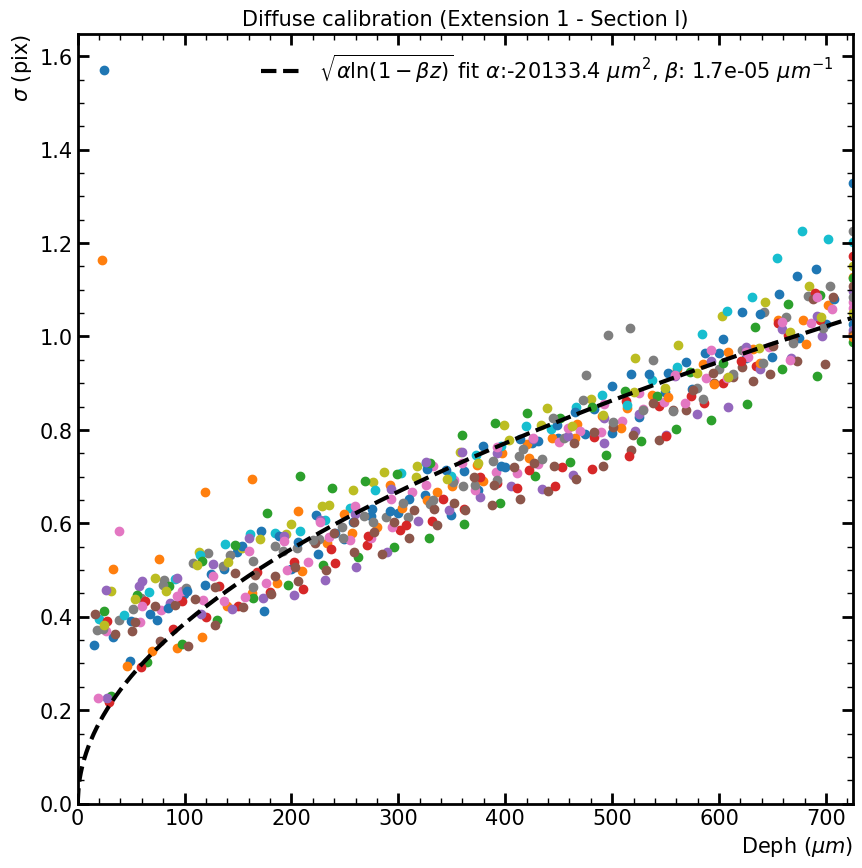

Warning in <TROOT::Append>: Replacing existing TH1: histogram (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: histogram (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: histogram (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: histogram (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: histogram (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: histogram (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: histogram (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: histogram (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: histogram (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: histogram (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: histogram (Potential memory leak).
Warning in <TROOT::Append>: Replacing exist

In [14]:
CCD_depth = 725 # micras
Bins = 50

extension = 1
label_muon = 1
img_sigma = 0.0003  # KeV 
# print(img_sigma)
fig, axs_all = plt.subplots(figsize = [10,10])

# Data 85 to 95 deg
# [39, 80, 81, 96, 210, 214, 233, 261, 294, 353, 406, 414, 426, 459, 532, 653, 760, 765, 915, 1096, 1121]

# Data 265 to 275 
# [58, 91, 114, 119, 121, 128, 143, 168, 173, 192, 253, 277, 288, 302, 306, 309, 321, 349, 362, 383, 385, 391, 404, 434, 451, 468, 516, 550, 588, 690, 793, 831, 864, 929, 1090, 1091]

# list_muonlabels0 = [80]
# list_muonlabels1 = [128]
list_muonlabels0 = [80, 261, 294, 353, 760, 765, 1121]
list_muonlabels1 = [121, 128, 168, 192, 302, 306, 434, 550, 793, 864, 929 , 1091]


list_muonlabels = list_muonlabels0 + list_muonlabels1
# list_muonlabels = list_muonlabels1

c3=TCanvas("c3", "", 800,800)
c3.Divide(7,7)

for label_muon in list_muonlabels: 
    Delta_inicial = 1    # px
    Delta_final = 5     # px
    event = list_datamask[label_muon]
    size_x = event.shape[1]
    size_y = event.shape[0]

    # lines = 0
    Longitud_XY = size_y 
    print("long: ", Longitud_XY)
    Z_inicial = (Delta_inicial * CCD_depth) / (Longitud_XY - Delta_final)
    # print('Muon: ', label_muon, ', Shape (X, Y): ', event.shape[1], event.shape[0])

    list_fitsigmas = []
    if label_muon in list_muonlabels1:
        Delta_inicial = Delta_final
        Delta_final = Delta_inicial


    for lable_line in range(Delta_inicial, size_y - Delta_final):
        line = event[lable_line - 1:lable_line][0]
        Carga_renglon = line.sum()/ratio_KeVelect
        Mean_carga = np.mean(line)/ratio_KeVelect
        Longitud_linea = len(line)


        Mean_in  = 0
        var = 0
        carga_cuadrada = 0

        ### Se calcula el X promedio ##
        for pixel in range(0, Longitud_linea):
            if line[pixel]:
                element_pixel = (pixel * line[pixel]/ratio_KeVelect) / Carga_renglon
                Mean_in = Mean_in + element_pixel
            else:
                element_pixel = 0
            
            Mean_in = Mean_in + element_pixel

        ## Calcula la suma de las cargas al cuadrado ##
        for pixel in np.arange(0, Longitud_linea, 1):
            if line[pixel]:
                element_pixel = (line[pixel]/ratio_KeVelect)**2
            else:
                element_pixel = 0

            carga_cuadrada = carga_cuadrada + element_pixel 

        Mean_carga_cuadrada = carga_cuadrada/Longitud_linea

        ### Se calcula la varianza ##
        for pixel in np.arange(0, Longitud_linea, 1):
            if line[pixel]:
                # element_pixel =(1 / (Longitud_linea - 1)) * (pixel - Mean_in)**2 * line[pixel]
                element_pixel =(1 / (Longitud_linea - 1)) * (pixel - Mean_in)**2
                var = var + element_pixel  ### COreggir la varianza con otro estimados

        ### Se corrige la varianza con la carga ###
        var_true = var * (Mean_carga_cuadrada / (Mean_carga**2))
        # var_true = var / Carga_renglon

        ### Se calcula la sigma ###
        sigma_in = np.sqrt(var_true)
        # print(sigma_in)
        # sigma_in = np.sqrt(var_true)


        ##Se crea un arreglo para usarlo en el plot de los datos, y se realiza el juste ##
        list_xlabel = np.arange(0.5, len(line), 1)


        ## Ajuste gaussiano con ROOT ##
        fgaus2 = TF1("fgauss","gaus",  0,  len(line.flatten()), 3) # TF1("nombre", "funcion escrita como en root", min, max, #parametros)
        h3=TH1F("histogram", "Distribution of Line", len(line.flatten()) + 1, 0,  len(line.flatten()) )

        for index in range(0, len(line)):
            if line[index] != 0:
                # print(index, line[index])
                h3.SetBinContent( index + 1, line[index]/ratio_KeVelect)
                err = np.sqrt((img_sigma/ratio_KeVelect)**2 + line[index]/ratio_KeVelect)
                h3.SetBinError(index + 1,err )
                # h3.SetBinError(index + 1, 0.001)
                #print(pixel_value)

        fgaus2.SetParameters(np.max(line),Mean_in,sigma_in) # Establecer parametros iniciales del fit, de manera visual es posible determinarlos como una primera aproximacion
        h3.Fit(fgaus2, "RQN")
        # h3.Fit(fgaus2, "RQNL")

        fit_const = fgaus2.GetParameters()[0]
        fit_mean = fgaus2.GetParameters()[1]
        fit_sigma = fgaus2.GetParameters()[2]


        # fit_sigma = sigma_in
        # print('Sigma fit: ', fit_sigma)
        list_fitsigmas.append(fit_sigma)

        c3.cd(lable_line)
        h3.Draw("same")
        fgaus2.Draw("same")
        # c3.Draw()
        # del h3

    list_deep = []
    list_xlabel_sigmas = np.linspace(Z_inicial, CCD_depth, len(list_fitsigmas))
    for deep in list_xlabel_sigmas:
        list_deep.append(deep)

    if label_muon in list_muonlabels1:
        # print('Gola', list_fitsigmas[0], list_fitsigmas[-1])
        list_fitsigmas.reverse()
        # print('Agios', list_fitsigmas[0], list_fitsigmas[-1], end='\n\n')

    # axs_all.scatter(list_deep, list_fitsigmas, label = 'Muon: ' + str(label_muon))
    axs_all.scatter(list_deep, list_fitsigmas)

def diffution_curve(z, alpha, beta):
    return np.sqrt((alpha * np.log(1 - (beta * z))))

fit_range = np.arange(0, 725)
Label = r'$\sqrt{\alpha \ln(1 - \beta z)}$ fit $\alpha$:' + str(np.around(fit_alpha, 1)) + r' $\mu m^{2}$, $\beta$: ' + str(np.around(fit_beta, 6)) + r' $\mu m^{-1}$'

# axs_all.plot(fit_range, diffution_curve(fit_range, alpha=-200, beta=0.001) / 15, '--r', linewidth = 3)
axs_all.plot(fit_range, diffution_curve(fit_range, alpha=fit_alpha, beta=fit_beta)/15, '--k', linewidth = 3, label= Label)
# axs_all.plot(fit_range, diffution_curve(fit_range, alpha=-292.4325743170209, beta=3.990904646095944e-06), '--c', linewidth = 2, label='Fit CONNIE')

axs_all.set_title('Diffuse calibration (Extension 1 - Section I)', size = 15)#, y=0.92)}
axs_all.set_ylabel(r'$\sigma$ (pix)')
axs_all.set_xlabel(r'Deph ($\mu m$)')
axs_all.set_ylim(0, )
axs_all.set_xlim(0, 725)
axs_all.legend()
axs_all.grid
plt.show()

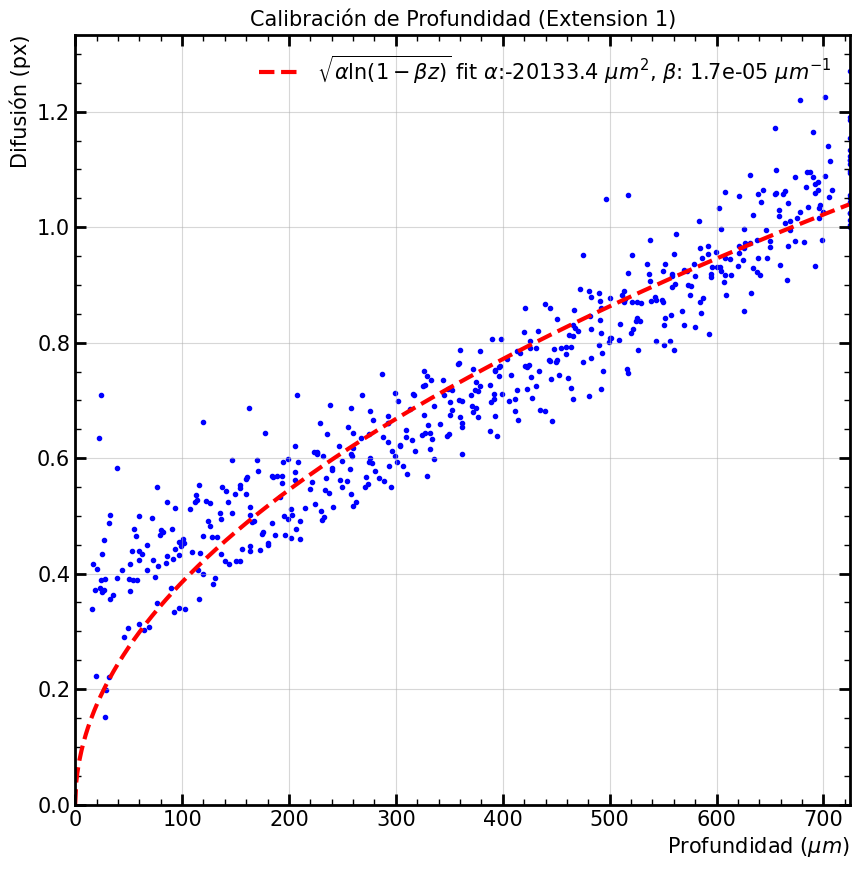

Warning in <TROOT::Append>: Replacing existing TH1: histogram (Potential memory leak).


In [15]:
img_sigma = 0.0008  # KeV 
# print(img_sigma)
fig, axs_all = plt.subplots(figsize = [10,10])

# list_muonlabels = [256, 257, 258]

list_all_sigmas = []
list_all_deeps = []

for label_muon in list_muonlabels: 
    Delta_inicial = 1    # px
    Delta_final = 5     # px
    event = list_datamask[label_muon]
    size_x = event.shape[1]
    size_y = event.shape[0]

    # lines = 0
    Longitud_XY = size_y 
    Z_inicial = (Delta_inicial * CCD_depth) / (Longitud_XY - Delta_final)
    # print('Muon: ', label_muon, ', Shape (X, Y): ', event.shape[1], event.shape[0])

    list_fitsigmas = []
    if label_muon in list_muonlabels1:
        Delta_inicial = Delta_final
        Delta_final = Delta_inicial

    for lable_line in range(Delta_inicial, size_y - Delta_final):
        line = event[lable_line - 1:lable_line][0]
        Carga_renglon = line.sum()
        Mean_carga = np.mean(line)
        Longitud_linea = len(line)


        Mean_in  = 0
        var = 0
        carga_cuadrada = 0

        ### Se calcula el X promedio ##
        for pixel in range(0, Longitud_linea):
            if line[pixel]:
                element_pixel = (pixel * line[pixel]) / Carga_renglon
                Mean_in = Mean_in + element_pixel
            else:
                element_pixel = 0
            
            Mean_in = Mean_in + element_pixel

        ## Calcula la suma de las cargas al cuadrado ##
        for pixel in np.arange(0, Longitud_linea, 1):
            if line[pixel]:
                element_pixel = line[pixel]**2
            else:
                element_pixel = 0

            carga_cuadrada = carga_cuadrada + element_pixel 

        Mean_carga_cuadrada = carga_cuadrada/Longitud_linea

        ### Se calcula la varianza ##
        for pixel in np.arange(0, Longitud_linea, 1):
            if line[pixel]:
                element_pixel =(1 / (Longitud_linea - 1)) * (pixel - Mean_in)**2 * line[pixel]
                var = var + element_pixel  ### COreggir la varianza con otro estimados

        ### Se corrige la varianza con la carga ###
        # var_true = var * (Mean_carga_cuadrada / (Mean_carga**2))
        var_true = var / Carga_renglon

        ### Se calcula la sigma ###
        sigma_in = np.sqrt(var)
        # print(sigma_in)
        # sigma_in = np.sqrt(var_true)


        ##Se crea un arreglo para usarlo en el plot de los datos, y se realiza el juste ##
        list_xlabel = np.arange(0.5, len(line), 1)


        ## Ajuste gaussiano con ROOT ##
        fgaus2 = TF1("fgauss","gaus",  0,  len(line.flatten()), 3) # TF1("nombre", "funcion escrita como en root", min, max, #parametros)
        h3=TH1F("histogram", "Distribution of Line", len(line.flatten()) + 1, 0,  len(line.flatten()) )

        for index in range(0, len(line)):
            if line[index] != 0:
                # print(index, line[index])
                h3.SetBinContent( index + 1, line[index])
                h3.SetBinError(index + 1, img_sigma)
                # h3.SetBinError(index + 1, 0.001)
                #print(pixel_value)

        fgaus2.SetParameters(np.max(line),Mean_in,sigma_in) # Establecer parametros iniciales del fit, de manera visual es posible determinarlos como una primera aproximacion
        h3.Fit(fgaus2, "RQN")

        fit_const = fgaus2.GetParameters()[0]
        fit_mean = fgaus2.GetParameters()[1]
        fit_sigma = fgaus2.GetParameters()[2]


        # fit_sigma = sigma_in
        # print('Sigma fit: ', fit_sigma)
        list_fitsigmas.append(fit_sigma)

        del h3

    list_deep = []
    list_xlabel_sigmas = np.linspace(Z_inicial, CCD_depth, len(list_fitsigmas))
    for deep in list_xlabel_sigmas:
        list_deep.append(deep)

    if label_muon in list_muonlabels1:
        # print('Gola', list_fitsigmas[0], list_fitsigmas[-1])
        list_fitsigmas.reverse()
        # print('Agios', list_fitsigmas[0], list_fitsigmas[-1], end='\n\n')
        
    for index in range(0, len(list_fitsigmas)):
        list_all_sigmas.append(list_fitsigmas[index])
        list_all_deeps.append(list_deep[index])

    # axs_all.scatter(list_deep, list_fitsigmas, marker='2', label = 'Muon: ' + str(label_muon))
del list_fitsigmas
del list_deep


fit_range = np.arange(0, 725)



axs_all.scatter(list_all_deeps, list_all_sigmas, marker='.', facecolor = 'b')

def diffution_curve(x, alpha, beta):
    return np.sqrt((alpha * np.log(1 - (beta * x))))

# popt_DM, _ = curve_fit(diffution_curve, list_all_deeps, list_all_sigmas, maxfev=100000, p0= [1, 1])
# dict_diffution_model = {'Alpha' : popt_DM[0], 'Beta' : popt_DM[1]}
# print('Alpha: ', dict_diffution_model['Alpha'], ' Beta: ', dict_diffution_model['Beta'])



axs_all.plot(fit_range, diffution_curve(fit_range, alpha=fit_alpha, beta=fit_beta)/15, '--r', linewidth = 3, label= Label)
# axs_all.plot(fit_range, diffution_curve(fit_range, -611, 0.00045)/15, '--r', linewidth = 3)

axs_all.set_title('Calibración de Profundidad (Extension 1)', size = 15)#, y=0.92)}
axs_all.set_ylabel(r'Difusión (px)')
axs_all.set_xlabel(r'Profundidad ($\mu m$)')
axs_all.set_ylim(0,)
axs_all.set_xlim(0, 725)
axs_all.legend()
axs_all.grid()
plt.show()

In [16]:
list_all_sigmas = []
list_all_deeps = []

for label_muon in list_muonlabels: 
    Delta_inicial = 1    # px
    Delta_final = 5     # px
    event = list_datamask[label_muon]
    size_x = event.shape[1]
    size_y = event.shape[0]

    # lines = 0
    Longitud_XY = size_y 
    Z_inicial = (Delta_inicial * CCD_depth) / (Longitud_XY - Delta_final)
    # print('Muon: ', label_muon, ', Shape (X, Y): ', event.shape[1], event.shape[0])

    list_fitsigmas = []
    if label_muon in list_muonlabels1:
        Delta_inicial = Delta_final
        Delta_final = Delta_inicial

    for lable_line in range(Delta_inicial, size_y - Delta_final):
        line = event[lable_line - 1:lable_line][0]
        Carga_renglon = line.sum()
        Mean_carga = np.mean(line)
        Longitud_linea = len(line)


        Mean_in  = 0
        var = 0
        carga_cuadrada = 0

        ### Se calcula el X promedio ##
        for pixel in range(0, Longitud_linea):
            if line[pixel]:
                element_pixel = (pixel * line[pixel]) / Carga_renglon
                Mean_in = Mean_in + element_pixel
            else:
                element_pixel = 0
            
            Mean_in = Mean_in + element_pixel

        ## Calcula la suma de las cargas al cuadrado ##
        for pixel in np.arange(0, Longitud_linea, 1):
            if line[pixel]:
                element_pixel = line[pixel]**2
            else:
                element_pixel = 0

            carga_cuadrada = carga_cuadrada + element_pixel 

        Mean_carga_cuadrada = carga_cuadrada/Longitud_linea

        ### Se calcula la varianza ##
        for pixel in np.arange(0, Longitud_linea, 1):
            if line[pixel]:
                element_pixel =(1 / (Longitud_linea - 1)) * (pixel - Mean_in)**2 * line[pixel]
                var = var + element_pixel  ### COreggir la varianza con otro estimados

        ### Se corrige la varianza con la carga ###
        # var_true = var * (Mean_carga_cuadrada / (Mean_carga**2))
        var_true = var / Carga_renglon

        ### Se calcula la sigma ###
        sigma_in = np.sqrt(var)
        # print(sigma_in)
        # sigma_in = np.sqrt(var_true)


        ##Se crea un arreglo para usarlo en el plot de los datos, y se realiza el juste ##
        list_xlabel = np.arange(0.5, len(line), 1)


        ## Ajuste gaussiano con ROOT ##
        fgaus2 = TF1("fgauss","gaus",  0,  len(line.flatten()), 3) # TF1("nombre", "funcion escrita como en root", min, max, #parametros)
        h3=TH1F("histogram", "Distribution of Line", len(line.flatten()) + 1, 0,  len(line.flatten()) )

        for index in range(0, len(line)):
            if line[index] != 0:
                # print(index, line[index])
                h3.SetBinContent( index + 1, line[index])
                h3.SetBinError(index + 1, img_sigma)
                # h3.SetBinError(index + 1, 0.001)
                #print(pixel_value)

        fgaus2.SetParameters(np.max(line),Mean_in,sigma_in) # Establecer parametros iniciales del fit, de manera visual es posible determinarlos como una primera aproximacion
        h3.Fit(fgaus2, "RQN")

        fit_const = fgaus2.GetParameters()[0]
        fit_mean = fgaus2.GetParameters()[1]
        fit_sigma = fgaus2.GetParameters()[2]


        # fit_sigma = sigma_in
        # print('Sigma fit: ', fit_sigma)
        list_fitsigmas.append(fit_sigma)

        del h3

    list_deep = []
    list_xlabel_sigmas = np.linspace(Z_inicial, CCD_depth, len(list_fitsigmas))
    for deep in list_xlabel_sigmas:
        list_deep.append(deep)

    if label_muon in list_muonlabels1:
        # print('Gola', list_fitsigmas[0], list_fitsigmas[-1])
        list_fitsigmas.reverse()
        # print('Agios', list_fitsigmas[0], list_fitsigmas[-1], end='\n\n')

    for index in range(0, len(list_fitsigmas)):
        list_all_sigmas.append(list_fitsigmas[index])
        list_all_deeps.append(list_deep[index])

    # axs_all.scatter(list_deep, list_fitsigmas, marker='2', label = 'Muon: ' + str(label_muon))
del list_fitsigmas
del list_deep



# fit_range = np.arange(0, 900)
# axs_all.scatter(list_all_deeps, list_all_sigmas, marker='2')
 
h_model = TGraph(len(list_all_sigmas), np.array(list_all_deeps),np.array(list_all_sigmas))
h_model.SetMarkerStyle(2) # Set marker style (e.g., solid circle)
h_model.SetTitle("Modelo de dif. (Extensión 1- Muones Verticales)")
h_model.GetXaxis().SetTitle("Profundidad (micras)")
h_model.GetYaxis().SetTitle("Anchura (micras)")
h_model.SetStats(0)
h_model.GetXaxis().SetRangeUser(0, 725)
h_model.GetYaxis().SetRangeUser(0, 1.4)



Range_fit = [0, 725]
diff_curve = TF1("diff_curve", "sqrt(([0] * log(1 - [1]*x)))/15", Range_fit[0], Range_fit[1], 2) #np.sqrt(np.abs(alpha * np.log(1 - (beta * z))))

diff_curve.SetParameters(-200, 0.00001) # Establecer parametros iniciales del fit, de manera visual es posible determinarlos como una primera aproximacion
h_model.Fit(diff_curve, "RNQ")

fit_alpha = diff_curve.GetParameters()[0]
fit_beta = diff_curve.GetParameters()[1]
chi2 = diff_curve.GetChisquare()
ndf = diff_curve.GetNDF()
prob = diff_curve.GetProb()

fit_alpha_err = diff_curve.GetParErrors()[0]
fit_beta_err = diff_curve.GetParErrors()[1]

print('Alpha: ', fit_alpha, '+- ', fit_alpha_err) 
print('Beta: ', fit_beta,  '+- ', fit_beta_err)
print('Chi2/ndf: ', chi2, '/', ndf)
print('Prob: ', prob)

c3=TCanvas("","", 1000, 600)
h_model.Draw("AP same")
diff_curve.Draw("same")
c3.Draw()

leg = TLegend(0.1,0.7,0.48,0.9)
leg.AddEntry(diff_curve, r"\sqrt{\alpha \log(1 - \beta z)} fit: \alpha= " + str(np.around(fit_alpha, 3)) + r" \mu m^2, \beta= " + str(np.around(fit_beta, 6)) + " \mu m^{-1}", "L")
leg.Draw()

Alpha:  -20133.445718261915 +-  8268.183939043374
Beta:  1.6574655310585046e-05 +-  6.778789682689249e-06
Chi2/ndf:  3.8547771461205724 / 516
Prob:  1.0


In [43]:
from array import array

spread_array = array('f', [-9999])
deep_array = array('f', [-9999])

location_file = './'
file_root_name = 'tree_DiffusionMod_Ext1_Vert.root'
file = TFile.Open(location_file  + file_root_name, "RECREATE")
tree = TTree('tree', 'tree')

tree.Branch('sprd', spread_array, 'sprd/F')
tree.Branch('deep', deep_array, 'deep/F')

for i in range(0, len(list_all_sigmas)):
    spread_array[0] = list_all_sigmas[i]
    deep_array[0] = list_all_deeps[i]
    
    tree.Fill()

tree.Write()
file.Close()

### Muones horizontales

#### DataFrame y visualización

In [125]:
### Se crea el dataframe y se selecciona un rango de datos ###
Ext = 1
DF_muons, list_datamask = DataFrame_muons(data_histogram, extension=Ext, units=1)
# display(DF_muons[450:500])
list_newmatrix = []
list_indexs =[]
#
# range_in_phi = DF_muons[DF_muons['Phi (Deg)'].between(0, 5)]  # Horizontales derecha 1
# range_in_phi = DF_muons[DF_muons['Phi (Deg)'].between(355, 360)]  # Horizontales derecha 2
range_in_phi = DF_muons[DF_muons['Phi (Deg)'].between(175, 185)]  # Horizontales izquierda

for index in range_in_phi.index:
    # print(index)
    list_newmatrix.append(list_datamask[index])
    list_indexs.append(index)

print(list_indexs)
list_phi_ext1 = data_histogram['extension_' + str(Ext)]['phi']
list_mask_rot = []

list_listsnxny = []

for index in list_indexs[:]:
    datamask = list_datamask[index]
    ylen, xlen = datamask.shape
    list_nxny = []

    data_mask_zeros = np.empty((ylen + 90, xlen+50))
    data_mask_zeros[:] = 0
    ylen_zeros, xlen_zeros = data_mask_zeros.shape
    # print(data_mask_zeros.shape)
    
    ### Angle rot ##
    phi_rot = np.pi/2 - list_phi_ext1[index]
    # print(phi_rot, phi_rot + list_phi_ext1[index])

    # print('shape original: ', xlen, ylen)
    # print('shape zeros: ', xlen_zeros, ylen_zeros)

    # for y_bin in range(0, ylen):
    #     for x_bin in range(0, xlen):
    #         if datamask[y_bin][x_bin] != 0:
    #             nx, ny = pixel_rot(x_bin=x_bin, x0=0, y_bin=y_bin, y0=0, theta= phi_rot)
    #             list_nxny.append((nx + 200, ny))
    #             # print(nx, ny)
    #             data_mask_zeros[ny][nx+200] = datamask[y_bin][x_bin]

    # list_listsnxny.append(list_nxny)
    # label_img, nlabels_img = sk.measure.label(data_mask_zeros > 0, connectivity=2, return_num=True)
    # loc = nd.find_objects(label_img == 1)[0]
    # mask_rot = np.invert(label_img==1)
    # # data_mask_rot = ma.masked_array(data_mask_zeros, mask_rot)
    # data_mask_rot = ma.masked_array(data_mask_zeros[loc[0].start:loc[0].stop, loc[1].start:loc[1].stop], mask_rot[loc[0].start:loc[0].stop, loc[1].start:loc[1].stop])

    # list_mask_rot.append(data_mask_rot)
    # print('Shape rot: ', data_mask_rot.shape[1], data_mask_rot.shape[0])
    
    # plt.imshow(data_mask_rot)
    # plt.show()

# print(list_mask_rot)
#     

[1, 16, 34, 37, 54, 64, 162, 293, 317, 330, 333, 343, 347, 371, 415, 416, 456, 486, 493, 501, 507, 534, 545, 574, 577, 584, 594, 609, 617, 626, 701, 707, 716, 723, 726, 736, 745, 756, 759, 773, 775, 816, 819, 828, 832, 847, 867, 878, 885, 898, 914, 933, 937, 941, 946, 949, 961, 982, 993, 995, 997, 1002, 1016, 1021, 1022, 1023, 1025, 1030, 1041, 1044, 1047, 1048, 1054, 1085, 1087, 1123, 1125]


,date_run,Gain (ADU/e-),Solidity,Elipticity,Theta (Deg),Phi (Deg),Charge (e-),l (cm),dEdL (KeV/cm)
Muon ID,,,,,,,,,
1002,ENE2025,220.86848,0.783784,0.871386,45.042719,183.493811,7019.971765,0.102607,2517.712467


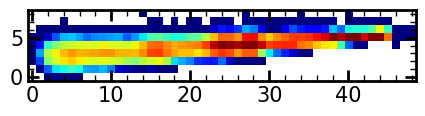

In [155]:
n_label = 1002
display(DF_muons.iloc[[n_label]])

figure , axs = plt.subplots(1,1,figsize=[5,5])
# axs.imshow(list_mask_rot[n_label],  cmap = ColorMap, norm=Norm)  
axs.imshow(list_datamask[n_label],  cmap = ColorMap, norm=Norm)
plt.show()


Numper of rows:  7
Long of line:  6


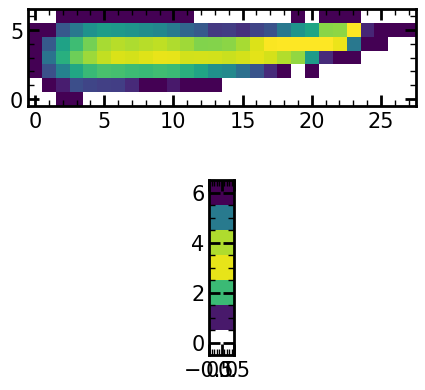

In [127]:
figure , axs = plt.subplots(2,1,figsize=[5,5])

label_muon = n_label
label_line = 10
muon = list_datamask[label_muon]
print('Numper of rows: ', muon.shape[0])
line = muon[:, label_line: label_line + 1]
# line = list_mask_rot[label_muon][label_line - 1:label_line][0]

n_longline = 0
for pixel in line:
    if pixel[0] != 0:
        # print(pixel)
        n_longline += 1

print('Long of line: ', n_longline)

# axs[0].imshow(list_mask_rot[label_muon], norm = Norm)
# axs[1].imshow(list_mask_rot[label_muon][label_line - 1:label_line], norm = Norm)

axs[0].imshow(muon, norm = Norm)
axs[1].imshow(muon[:, label_line: label_line + 1], norm = Norm)
plt.show()

In [128]:
list_index_long_muons = []
extension = 1

for index in range(0, len(list_newmatrix)):
    size_x = list_newmatrix[index].shape[1]
    # size_y = list_datamask[index].shape[0]
    if size_x > 10:
        # print(size_x, size_y)
        list_index_long_muons.append(list_indexs[index])

# print(list_index_long_muons)+
print('Muones largos detectados: ', len(list_index_long_muons))
print('Indices: ', list_index_long_muons)

Muones largos detectados:  77
Indices:  [1, 16, 34, 37, 54, 64, 162, 293, 317, 330, 333, 343, 347, 371, 415, 416, 456, 486, 493, 501, 507, 534, 545, 574, 577, 584, 594, 609, 617, 626, 701, 707, 716, 723, 726, 736, 745, 756, 759, 773, 775, 816, 819, 828, 832, 847, 867, 878, 885, 898, 914, 933, 937, 941, 946, 949, 961, 982, 993, 995, 997, 1002, 1016, 1021, 1022, 1023, 1025, 1030, 1041, 1044, 1047, 1048, 1054, 1085, 1087, 1123, 1125]


#### Perfil energético

Thet angle: 67.58775954465384
Number of rows:  12


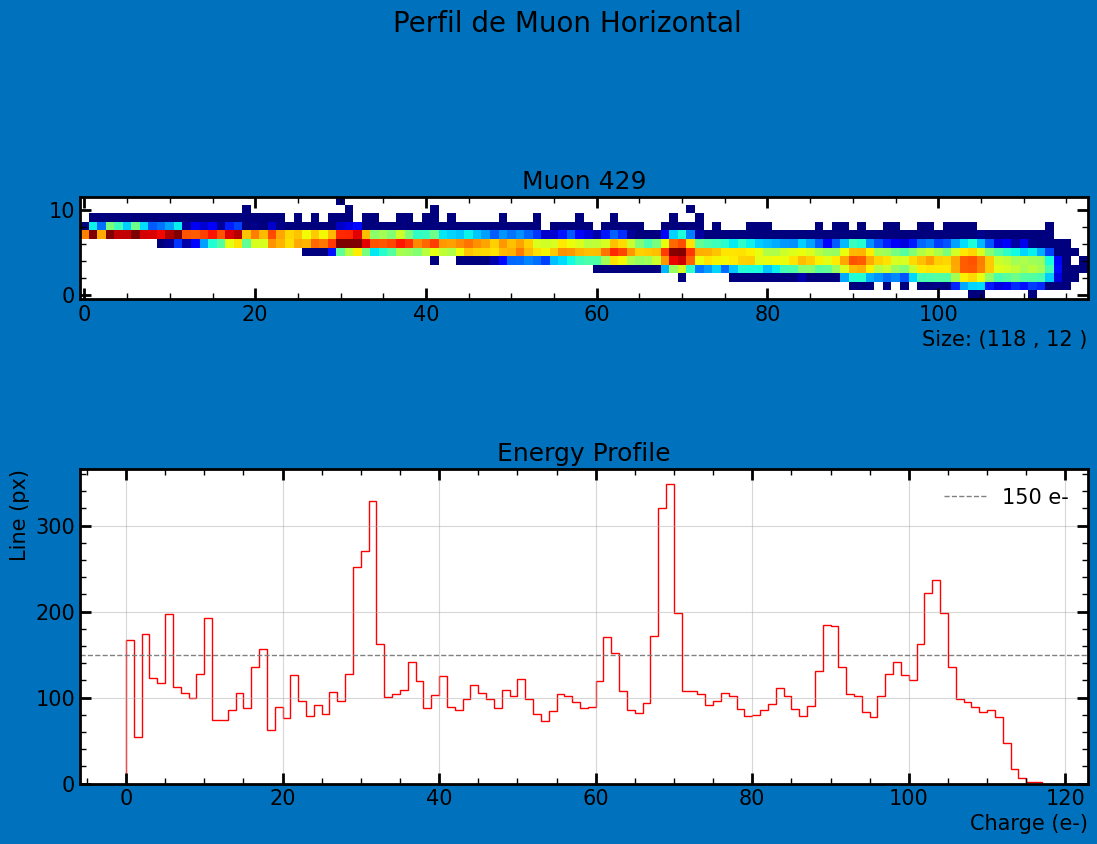

In [183]:
# [857,948],
# [73,110,204,280,329,448,770],
# [330, 371, 773, 914, 1002, 1023]

muon_label = 429 # Se coloca directamente el label del evento
thet = DF_muons.iloc[[muon_label]]['Theta (Deg)'].values[0]
print(f"Thet angle: {thet}")

Delta_inicial = 0
Delta_final = 0
extension = 1

fig, axs = plt.subplots(ncols=1, nrows=2, figsize = [13,9], facecolor = [0, 0.4470, 0.7410])
fig.suptitle('Perfil de Muon Horizontal', y = 0.97, size = 20)
event = list_datamask[muon_label]
# plt.imshow(event)

size_x = event.shape[1] # tamaño en x
size_y = event.shape[0] # tamaño en y
# print(event.sum())

print('Number of rows: ', event.shape[0])
charge_horizontalMuon = []
for index in range(1, size_x):
    line = event[:, index: index + 1]/ratio_KeVelect
    # line = event[index - 1:index][0]
    # print(line)

    charge = line.sum()
    # print(charge, end="\n\n")
    charge_horizontalMuon.append(charge)

        
# cmap = 'plasma'
axs[0].imshow(event, cmap = ColorMap, norm = Norm)#, origin='upper')
axs[0].set_title('Muon ' + str(muon_label))
axs[0].set_xlabel('Size: (' + str(size_x) + ' , ' + str(size_y) + ' )')
# x0bar = fig.colorbar(x0, ax=axs[0])

# en_cor = 150 # HRIGHT1
# en_cor = 250 # HRIGHT2
en_cor = 150

axs[1].stairs(charge_horizontalMuon, range(0,len(charge_horizontalMuon)+1),  orientation='vertical', color = 'r')#,  hatch = '////')
axs[1].axhline(en_cor, 0, size_x+2, linestyle='--', color='gray', label = str(np.around(en_cor, 3)) +  ' e-')
# axs[1].vlines(x = mean_charge, ymin = 0, ymax = len(event) - 1, color = 'k', label = 'Mean Charge \n' + str(mean_charge))

# axs[1].set_ylim(0, size_x)
# axs[1].set_xlim(0, 4000)


# axs[1].set_xlabel('Charge (KeV)')
axs[1].set_xlabel('Charge (e-)')
axs[1].set_ylabel('Line (px)')
# axs[1].set_ylim(0,len(event) - 1 )
axs[1].set_title('Energy Profile')
axs[1].legend()
axs[1].grid()
plt.show()

#### XYE files

In [8]:
muon_label = 19

for n_label in list_index_long_muons:
    event = list_datamask[n_label]
    # plt.imshow(event)

    size_x = event.shape[1] # tamaño en x
    size_y = event.shape[0] # tamaño en y

    qT = 0
    list_xval = []
    list_yval = []
    list_eval = []

    for index in range(0, size_y):
        qLine = 0
        for jndex in range(0, size_x):
            if event[index][jndex]:
                # print(event[index][jndex])
                x_val, y_val, e_val = jndex,index, event[index][jndex]/0.00368
                # print(e_val)

                list_xval.append(x_val)
                list_yval.append(y_val)
                list_eval.append(e_val)
                qT +=  e_val
                qLine += e_val
        # print(qLine)
    print(qT, " e-")

    # with open(f"muons_ext1HRIGHT1/muon{n_label}.xye","w") as file:
    # with open(f"muons_ext1HRIGHT2/muon{n_label}.xye","w") as file:
    with open(f"muons_ext1HLEFT/muon{n_label}.xye","w") as file:
        for index in range(0, len(list_xval)):
            x_val = list_xval[index]
            y_val = list_yval[index]
            e_val = list_eval[index]
            file.write(f"{x_val} {y_val} {e_val} \n")



51502.203  e-
52743.082  e-
113493.28  e-
52957.523  e-
71275.31  e-
128287.016  e-
28521.504  e-
63675.984  e-
74475.79  e-
74004.07  e-
49568.574  e-
63837.992  e-
51693.324  e-
91075.52  e-
170155.27  e-
81771.19  e-
36070.914  e-
71679.484  e-
61420.977  e-
97733.29  e-
52181.13  e-
88951.766  e-
47838.086  e-
34588.844  e-
101709.44  e-
34516.645  e-
70924.09  e-
41115.785  e-
57862.79  e-
31945.916  e-
64089.805  e-
44464.953  e-
55266.645  e-
81374.164  e-
89174.805  e-
59319.938  e-
169643.0  e-
62360.895  e-
56805.688  e-
69595.22  e-
129633.07  e-
126814.92  e-
91320.64  e-
135846.92  e-
39659.797  e-
58416.258  e-
68911.68  e-
59686.027  e-
94290.02  e-
60532.0  e-
170653.44  e-
40793.164  e-
30701.256  e-
51581.504  e-
79457.12  e-
36653.855  e-
96427.01  e-
63567.25  e-
44395.344  e-
33901.543  e-
82491.54  e-
70199.73  e-
130132.29  e-
37317.348  e-
81578.77  e-
105983.54  e-
69075.336  e-
80152.914  e-
56501.766  e-
134795.34  e-
86913.96  e-
64932.13  e-
75739.33  e-
37

#### Modelo Difusión

In [24]:
CCD_depth = 725 # micras
Delta_inicial = 3    # px
Delta_final = 6     # px
Bins = 50

extension = 1
label_muon = 36
lable_line = 12
img_sigma = 0.0003  # KeV 
# print(img_sigma)

## Se checa si el muon tiene la orientación correcta
event = list_datamask[label_muon]
size_x = event.shape[1]
size_y = event.shape[0]

# lines = 0
Longitud_XY = size_x 
Longitud_linea = size_y

Z_inicial = (Delta_inicial * CCD_depth) / (Longitud_XY - Delta_final)


line = event[:, lable_line: lable_line + 1]
Carga_renglon = line.sum()
Mean_carga = np.mean(line)
# print(Carga_renglon, Mean_carga, len(line))


Mean_in  = 0
var = 0
carga_cuadrada = 0

### Se calcula el X promedio ##
for pixel in range(0, Longitud_linea, 1):
    if line[pixel][0]:
        element_pixel = (pixel * line[pixel][0]) / Carga_renglon
        Mean_in = Mean_in + element_pixel
    else:
        element_pixel = 0
    
    Mean_in = Mean_in + element_pixel

## Calcula la suma de las cargas al cuadrado ##
for pixel in range(0, Longitud_linea, 1):
    if line[pixel][0]:
        # print(line[pixel])
        element_pixel = line[pixel][0]**2
    else:
        element_pixel = 0

    carga_cuadrada = carga_cuadrada + element_pixel 

Mean_carga_cuadrada = carga_cuadrada/Longitud_linea

### Se calcula la varianza ##
for pixel in range(0, Longitud_linea, 1):
    element_pixel =(1 / (Longitud_linea - 1)) * (pixel - Mean_in)**2
    var = var + element_pixel  ### COreggir la varianza con otro estimados

### Se corrige la varianza con la carga ###
var_true = var * (Mean_carga_cuadrada / (Mean_carga**2))

### Se calcula la sigma ###
sigma_in = np.sqrt(var)
# sigma_in = np.sqrt(var_true)


##Se crea un arreglo para usarlo en el plot de los datos, y se realiza el juste ##
list_xlabel = np.arange(0.5, len(line), 1)
print('Lonitud de la linea: ', len(line))

## Ajuste gaussiano con ROOT ##
fgaus2 = TF1("fgauss","gaus",  0,  len(line), 3) # TF1("nombre", "funcion escrita como en root", min, max, #parametros)
h3=TH1F("histogram", "Distribution of Line", len(line) + 1, 0,  len(line) )

for index in range(0, len(line)):
    if line[index][0] != 0:
        # print(index, line[index])
        h3.SetBinContent( index + 1, line[index][0])
        h3.SetBinError(index + 1, img_sigma)
        # h3.SetBinError(index + 1, 0.001)
        #print(pixel_value)

fgaus2.SetParameters(np.max(line),Mean_in,sigma_in) # Establecer parametros iniciales del fit, de manera visual es posible determinarlos como una primera aproximacion
h3.Fit(fgaus2, "RQN")

fit_const = fgaus2.GetParameters()[0]
fit_mean = fgaus2.GetParameters()[1]
fit_sigma = fgaus2.GetParameters()[2]
print('Sigma fit: ', fit_sigma, end='\n\n')

c3=TCanvas()

h3.Draw()
c3.Draw()
fgaus2.Draw("same")

Lonitud de la linea:  14
Sigma fit:  0.4430840416489532



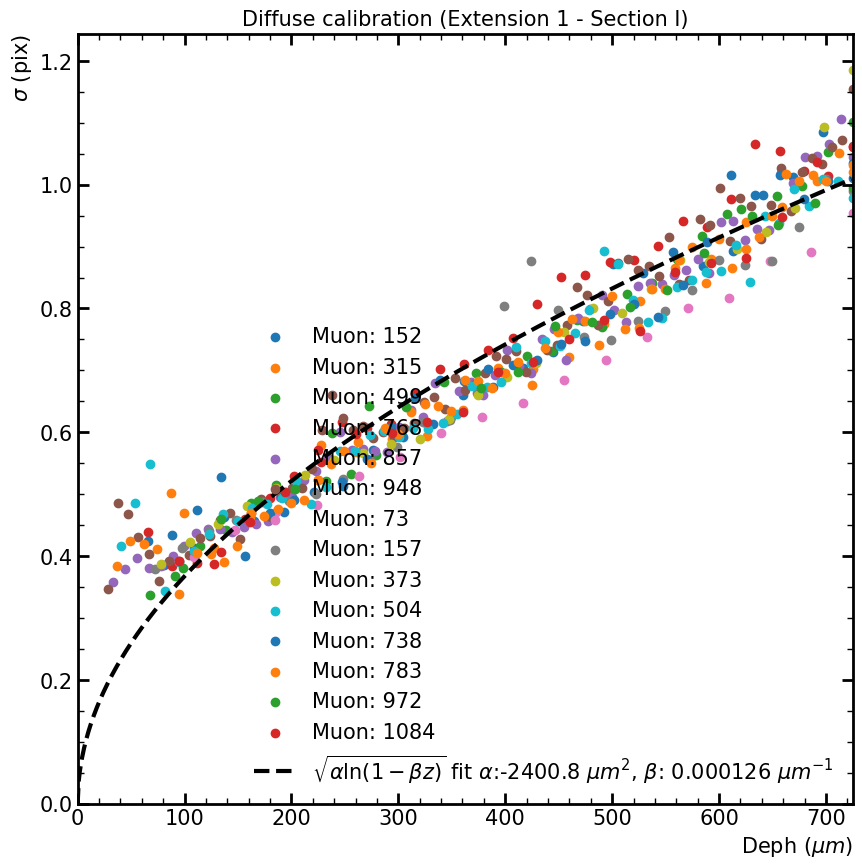

Warning in <TROOT::Append>: Replacing existing TH1: histogram (Potential memory leak).


In [25]:
CCD_depth = 725 # micras
Delta_inicial = 3    # px
Delta_final = 8     # px
Bins = 50

extension = 1
img_sigma = 0.0008  # KeV 
# print(img_sigma)
fig, axs_all = plt.subplots(figsize = [10,10])

# Data for phi between 0 to 5 deg
# [36, 57, 61, 152, 188, 254, 262, 265, 266, 271, 315, 316, 320, 348, 444, 454, 499, 500, 505, 573, 632, 637, 686, 703, 768, 771, 815, 818, 824, 836, 857, 909, 948, 956, 963]

# Data for phi between 355 to 360 deg
# [21, 73, 107, 110, 157, 199, 204, 280, 329, 373, 429, 448, 504, 587, 591, 604, 659, 738, 743, 758, 770, 783, 810, 841, 844, 855, 918, 920, 972, 974, 1014, 1061, 1084, 1114]

# Data for phi between 175 to 185 
# [1, 16, 34, 37, 54, 64, 162, 293, 317, 330, 333, 343, 347, 371, 415, 416, 456, 486, 493, 501, 507, 534, 545, 574, 577, 584, 594, 609, 617, 626, 701, 707, 716, 723, 726, 736, 
# 745, 756, 759, 773, 775, 816, 819, 828, 832, 847, 867, 878, 885, 898, 914, 933, 937, 941, 946, 949, 961, 982, 993, 995, 997, 1002, 1016, 1021, 1022, 1023, 1025, 1030, 1041, 
# 1044, 1047, 1048, 1054, 1085, 1087, 1123, 1125]

# list_muonlabels0 = [57, 152, 188, 254, 266, 315, 316, 499, 768, 836,  857, 948] # Phi 0 to 5 deg
# list_muonlabels1= [73, 110, 157, 204, 280, 329, 373, 448, 504, 738, 783,  844, 972, 1084, 1114] # Phi 355 to 360
# list_muonlabels2= [34, 54, 64, 330, 371, 416, 486, 773, 775, 819, 885, 914, 997, 1002, 1023, 1030, 1044] # Phi 175 to 185

list_muonlabels0 = [152, 315, 499, 768,  857, 948] # Phi 0 to 5 deg
list_muonlabels1= [73, 157, 373, 504, 738, 783, 972, 1084] # Phi 355 to 360
list_muonlabels2= [330, 371, 416, 486, 997, 1002, 1023] # Phi 175 to 185

# print(list_muonlabels0 +  list_muonlabels1)
# list_muonlabels = list_muonlabels0  +  list_muonlabels1  +  list_muonlabels2 
list_muonlabels = list_muonlabels0  +  list_muonlabels1 
# list_muonlabels = list_muonlabels2


for label_muon in list_muonlabels: 
    event = list_datamask[label_muon]
    size_x = event.shape[1]
    size_y = event.shape[0]

    # lines = 0
    Longitud_XY = size_x 
    Z_inicial = (Delta_inicial * CCD_depth) / (Longitud_XY - Delta_final)
    # print('Muon: ', label_muon, ', Shape (X, Y): ', event.shape[1], event.shape[0])

    list_fitsigmas = []
    if label_muon in list_muonlabels2:
        Delta_inicial = Delta_final
        Delta_final = Delta_inicial


    for lable_line in range(Delta_inicial, size_x - Delta_final):
        # print(label_line)
        line = event[:, lable_line: lable_line + 1]
        Carga_renglon = line.sum()
        Mean_carga = np.mean(line)
        Longitud_linea = len(line)

        Mean_in  = 0
        var = 0
        carga_cuadrada = 0

        ### Se calcula el X promedio ##
        for pixel in range(0, Longitud_linea):
            if line[pixel][0]:
                element_pixel = (pixel * line[pixel][0]) / Carga_renglon
                Mean_in = Mean_in + element_pixel
            else:
                element_pixel = 0
            
            Mean_in = Mean_in + element_pixel

        ## Calcula la suma de las cargas al cuadrado ##
        for pixel in range(0, Longitud_linea, 1):
            if line[pixel][0]:
                element_pixel = line[pixel][0]**2
            else:
                element_pixel = 0

            carga_cuadrada = carga_cuadrada + element_pixel 

        Mean_carga_cuadrada = carga_cuadrada/Longitud_linea

        ### Se calcula la varianza ##
        for pixel in range(0, Longitud_linea, 1):
            if line[pixel][0]:
                element_pixel =(1 / (Longitud_linea - 1)) * (pixel - Mean_in)**2 * line[pixel][0]
                # element_pixel =(1 / (Longitud_linea - 1)) * (pixel - Mean_in)**2
                var = var + element_pixel  ### COreggir la varianza con otro estimados

        ### Se corrige la varianza con la carga ###
        var_true = var * (Mean_carga_cuadrada / (Mean_carga**2))
        # var_true = var / Carga_renglon

        ### Se calcula la sigma ###
        sigma_in = np.sqrt(var_true)
        # print(sigma_in)
        # sigma_in = np.sqrt(var_true)


        ##Se crea un arreglo para usarlo en el plot de los datos, y se realiza el juste ##
        list_xlabel = np.arange(0.5, len(line), 1)


        ## Ajuste gaussiano con ROOT ##
        fgaus2 = TF1("fgauss","gaus",  0,  len(line), 3) # TF1("nombre", "funcion escrita como en root", min, max, #parametros)
        h3=TH1F("histogram", "Distribution of Line", len(line) + 1, 0,  len(line) )

        for index in range(0, len(line)):
            if line[index][0] != 0:
                # print(index, line[index])
                h3.SetBinContent( index + 1, line[index][0])
                h3.SetBinError(index + 1, img_sigma)
                # h3.SetBinError(index + 1, 0.001)
                #print(pixel_value)

        fgaus2.SetParameters(np.max(line),Mean_in,sigma_in) # Establecer parametros iniciales del fit, de manera visual es posible determinarlos como una primera aproximacion
        h3.Fit(fgaus2, "RQN")

        fit_const = fgaus2.GetParameters()[0]
        fit_mean = fgaus2.GetParameters()[1]
        fit_sigma = fgaus2.GetParameters()[2]


        # fit_sigma = sigma_in
        # print('Sigma fit: ', fit_sigma)
        list_fitsigmas.append(fit_sigma)

        del h3

    list_deep = []
    list_xlabel_sigmas = np.linspace(Z_inicial, CCD_depth, len(list_fitsigmas))
    for deep in list_xlabel_sigmas:
        list_deep.append(deep)

    if label_muon in list_muonlabels2:
        list_fitsigmas.reverse()

    axs_all.scatter(list_deep, list_fitsigmas, label = 'Muon: ' + str(label_muon))
    # axs_all.scatter(list_deep, list_fitsigmas)


def diffution_curve(z, alpha, beta):
    return np.sqrt((alpha * np.log(1 - (beta * z))))

fit_range = np.arange(0, 725)
# fit_alpha, fit_beta = -348.2, 0.000702
Label = r'$\sqrt{\alpha \ln(1 - \beta z)}$ fit $\alpha$:' + str(np.around(fit_alpha, 1)) + r' $\mu m^{2}$, $\beta$: ' + str(np.around(fit_beta, 6)) + r' $\mu m^{-1}$'

# axs_all.plot(fit_range, diffution_curve(fit_range, alpha=-200, beta=0.001) / 15, '--r', linewidth = 3)
axs_all.plot(fit_range, diffution_curve(fit_range, alpha=fit_alpha, beta=fit_beta)/15, '--k', linewidth = 3, label= Label)
# axs_all.plot(fit_range, diffution_curve(fit_range, alpha=-292.4325743170209, beta=3.990904646095944e-06), '--c', linewidth = 2, label='Fit CONNIE')

axs_all.set_title('Diffuse calibration (Extension 1 - Section I)', size = 15)#, y=0.92)}
axs_all.set_ylabel(r'$\sigma$ (pix)')
axs_all.set_xlabel(r'Deph ($\mu m$)')
axs_all.set_ylim(0, )
axs_all.set_xlim(0, 725)
axs_all.legend()
axs_all.grid
plt.show()

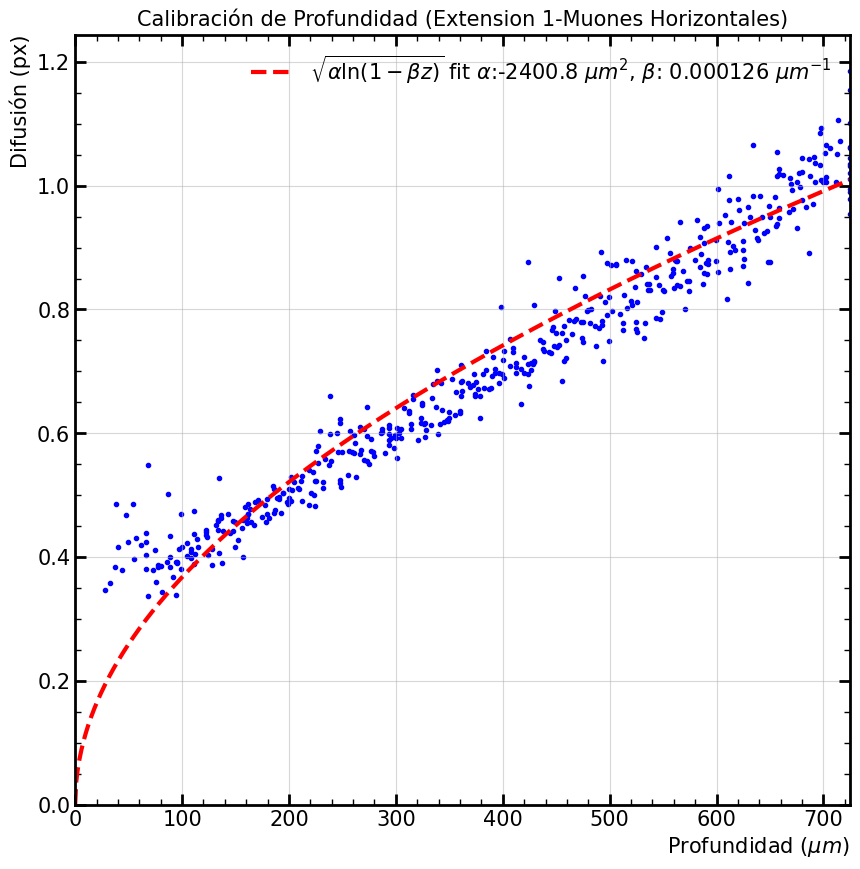

In [26]:
img_sigma = 0.0008  # KeV 
# print(img_sigma)
fig, axs_all = plt.subplots(figsize = [10,10])

# list_muonlabels = [256, 257, 258]

list_all_sigmas = []
list_all_deeps = []

for label_muon in list_muonlabels: 
    event = list_datamask[label_muon]
    size_x = event.shape[1]
    size_y = event.shape[0]

    # lines = 0
    Longitud_XY = size_x
    Z_inicial = (Delta_inicial * CCD_depth) / (Longitud_XY - Delta_final)
    # print('Muon: ', label_muon, ', Shape (X, Y): ', event.shape[1], event.shape[0])

    list_fitsigmas = []
    if label_muon in list_muonlabels2:
        Delta_inicial = Delta_final
        Delta_final = Delta_inicial

    for lable_line in range(Delta_inicial, size_x - Delta_final):
        line = event[:, lable_line: lable_line + 1]
        Carga_renglon = line.sum()
        Mean_carga = np.mean(line)
        Longitud_linea = len(line)


        Mean_in  = 0
        var = 0
        carga_cuadrada = 0

        ### Se calcula el X promedio ##
        for pixel in range(0, Longitud_linea):
            if line[pixel][0]:
                element_pixel = (pixel * line[pixel][0]) / Carga_renglon
                Mean_in = Mean_in + element_pixel
            else:
                element_pixel = 0
            
            Mean_in = Mean_in + element_pixel

        ## Calcula la suma de las cargas al cuadrado ##
        for pixel in range(0, Longitud_linea, 1):
            if line[pixel][0]:
                element_pixel = line[pixel][0]**2
            else:
                element_pixel = 0

            carga_cuadrada = carga_cuadrada + element_pixel 

        Mean_carga_cuadrada = carga_cuadrada/Longitud_linea

        ### Se calcula la varianza ##
        for pixel in range(0, Longitud_linea, 1):
            if line[pixel][0]:
                element_pixel =(1 / (Longitud_linea - 1)) * (pixel - Mean_in)**2 * line[pixel][0]
                var = var + element_pixel  ### COreggir la varianza con otro estimados

        ### Se corrige la varianza con la carga ###
        # var_true = var * (Mean_carga_cuadrada / (Mean_carga**2))
        var_true = var / Carga_renglon

        ### Se calcula la sigma ###
        sigma_in = np.sqrt(var)
        # print(sigma_in)
        # sigma_in = np.sqrt(var_true)


        ##Se crea un arreglo para usarlo en el plot de los datos, y se realiza el juste ##
        list_xlabel = np.arange(0.5, len(line), 1)


        ## Ajuste gaussiano con ROOT ##
        fgaus2 = TF1("fgauss","gaus",  0,  len(line), 3) # TF1("nombre", "funcion escrita como en root", min, max, #parametros)
        h3=TH1F("histogram", "Distribution of Line", len(line) + 1, 0,  len(line) )

        for index in range(0, len(line)):
            if line[index][0] != 0:
                # print(index, line[index])
                h3.SetBinContent( index + 1, line[index][0])
                h3.SetBinError(index + 1, img_sigma)
                # h3.SetBinError(index + 1, 0.001)
                #print(pixel_value)

        fgaus2.SetParameters(np.max(line),Mean_in,sigma_in) # Establecer parametros iniciales del fit, de manera visual es posible determinarlos como una primera aproximacion
        h3.Fit(fgaus2, "RQN")

        fit_const = fgaus2.GetParameters()[0]
        fit_mean = fgaus2.GetParameters()[1]
        fit_sigma = fgaus2.GetParameters()[2]


        # fit_sigma = sigma_in
        # print('Sigma fit: ', fit_sigma)
        list_fitsigmas.append(fit_sigma)

        del h3

    list_deep = []
    list_xlabel_sigmas = np.linspace(Z_inicial, CCD_depth, len(list_fitsigmas))
    for deep in list_xlabel_sigmas:
        list_deep.append(deep)

    # if label_muon in (143, 302, 321, 362, 383, 385, 404, 434, 550, 793, 864, 929, 1090, 1091):
    #     # print('Gola', list_fitsigmas[0], list_fitsigmas[-1])
    #     list_fitsigmas.reverse()
    #     # print('Agios', list_fitsigmas[0], list_fitsigmas[-1], end='\n\n')
    if label_muon in list_muonlabels2:
        list_fitsigmas.reverse()
        
    for index in range(0, len(list_fitsigmas)):
        list_all_sigmas.append(list_fitsigmas[index])
        list_all_deeps.append(list_deep[index])

    # axs_all.scatter(list_deep, list_fitsigmas, marker='2', label = 'Muon: ' + str(label_muon))
del list_fitsigmas
del list_deep


fit_range = np.arange(0, 725)

axs_all.scatter(list_all_deeps, list_all_sigmas, marker='.', facecolor = 'b')

def diffution_curve(x, alpha, beta):
    return np.sqrt((alpha * np.log(1 - (beta * x))))

# popt_DM, _ = curve_fit(diffution_curve, list_all_deeps, list_all_sigmas, maxfev=100000, p0= [1, 1])
# dict_diffution_model = {'Alpha' : popt_DM[0], 'Beta' : popt_DM[1]}
# print('Alpha: ', dict_diffution_model['Alpha'], ' Beta: ', dict_diffution_model['Beta'])



axs_all.plot(fit_range, diffution_curve(fit_range, alpha=fit_alpha, beta=fit_beta)/15, '--r', linewidth = 3, label= Label)
# axs_all.plot(fit_range, diffution_curve(fit_range, -611, 0.00045)/15, '--r', linewidth = 3)

axs_all.set_title('Calibración de Profundidad (Extension 1-Muones Horizontales)', size = 15)#, y=0.92)}
axs_all.set_ylabel(r'Difusión (px)')
axs_all.set_xlabel(r'Profundidad ($\mu m$)')
axs_all.set_ylim(0,)
axs_all.set_xlim(0, 725)
axs_all.legend()
axs_all.grid()
plt.show()

In [27]:
list_all_sigmas = []
list_all_deeps = []

for label_muon in list_muonlabels: 
    event = list_datamask[label_muon]
    size_x = event.shape[1]
    size_y = event.shape[0]

    # lines = 0
    Longitud_XY = size_x
    Z_inicial = (Delta_inicial * CCD_depth) / (Longitud_XY - Delta_final)
    # print('Muon: ', label_muon, ', Shape (X, Y): ', event.shape[1], event.shape[0])

    list_fitsigmas = []
    if label_muon in list_muonlabels2:
        Delta_inicial = Delta_final
        Delta_final = Delta_inicial

    for lable_line in range(Delta_inicial, size_x - Delta_final):
        line = event[:, lable_line: lable_line + 1]
        Carga_renglon = line.sum()
        Mean_carga = np.mean(line)
        Longitud_linea = len(line)


        Mean_in  = 0
        var = 0
        carga_cuadrada = 0

        ### Se calcula el X promedio ##
        for pixel in range(0, Longitud_linea):
            if line[pixel][0]:
                element_pixel = (pixel * line[pixel][0]) / Carga_renglon
                Mean_in = Mean_in + element_pixel
            else:
                element_pixel = 0
            
            Mean_in = Mean_in + element_pixel

        ## Calcula la suma de las cargas al cuadrado ##
        for pixel in range(0, Longitud_linea, 1):
            if line[pixel][0]:
                element_pixel = line[pixel][0]**2
            else:
                element_pixel = 0

            carga_cuadrada = carga_cuadrada + element_pixel 

        Mean_carga_cuadrada = carga_cuadrada/Longitud_linea

        ### Se calcula la varianza ##
        for pixel in range(0, Longitud_linea, 1):
            if line[pixel][0]:
                element_pixel =(1 / (Longitud_linea - 1)) * (pixel - Mean_in)**2 * line[pixel][0]
                var = var + element_pixel  ### COreggir la varianza con otro estimados

        ### Se corrige la varianza con la carga ###
        # var_true = var * (Mean_carga_cuadrada / (Mean_carga**2))
        var_true = var / Carga_renglon

        ### Se calcula la sigma ###
        sigma_in = np.sqrt(var)
        # print(sigma_in)
        # sigma_in = np.sqrt(var_true)


        ##Se crea un arreglo para usarlo en el plot de los datos, y se realiza el juste ##
        list_xlabel = np.arange(0.5, len(line), 1)


        ## Ajuste gaussiano con ROOT ##
        fgaus2 = TF1("fgauss","gaus",  0,  len(line), 3) # TF1("nombre", "funcion escrita como en root", min, max, #parametros)
        h3=TH1F("histogram", "Distribution of Line", len(line) + 1, 0,  len(line) )

        for index in range(0, len(line)):
            if line[index][0] != 0:
                # print(index, line[index])
                h3.SetBinContent( index + 1, line[index][0])
                h3.SetBinError(index + 1, img_sigma)
                # h3.SetBinError(index + 1, 0.001)
                #print(pixel_value)

        fgaus2.SetParameters(np.max(line),Mean_in,sigma_in) # Establecer parametros iniciales del fit, de manera visual es posible determinarlos como una primera aproximacion
        h3.Fit(fgaus2, "RQN")

        fit_const = fgaus2.GetParameters()[0]
        fit_mean = fgaus2.GetParameters()[1]
        fit_sigma = fgaus2.GetParameters()[2]


        # fit_sigma = sigma_in
        # print('Sigma fit: ', fit_sigma)
        list_fitsigmas.append(fit_sigma)

        del h3

    list_deep = []
    list_xlabel_sigmas = np.linspace(Z_inicial, CCD_depth, len(list_fitsigmas))
    for deep in list_xlabel_sigmas:
        list_deep.append(deep)

    if label_muon in list_muonlabels2:
        list_fitsigmas.reverse()

    for index in range(0, len(list_fitsigmas)):
        list_all_sigmas.append(list_fitsigmas[index])
        list_all_deeps.append(list_deep[index])

    # axs_all.scatter(list_deep, list_fitsigmas, marker='2', label = 'Muon: ' + str(label_muon))
del list_fitsigmas
del list_deep



# fit_range = np.arange(0, 900)
# axs_all.scatter(list_all_deeps, list_all_sigmas, marker='2')
 
h_model = TGraph(len(list_all_sigmas), np.array(list_all_deeps),np.array(list_all_sigmas))
h_model.SetMarkerStyle(2) # Set marker style (e.g., solid circle)
h_model.SetTitle("Modelo de dif. (Extensión 1- Muones Horizontales)")
h_model.GetXaxis().SetTitle("Profundidad (micras)")
h_model.GetYaxis().SetTitle("Anchura (micras)")
h_model.GetYaxis().SetRangeUser(0, 1.2)



Range_fit = [50, 725]
diff_curve = TF1("diff_curve", "sqrt(([0] * log(1 - [1]*x)))/15", Range_fit[0], Range_fit[1], 2) #np.sqrt(np.abs(alpha * np.log(1 - (beta * z))))

diff_curve.SetParameters(-200, 0.00001) # Establecer parametros iniciales del fit, de manera visual es posible determinarlos como una primera aproximacion
h_model.Fit(diff_curve, "RNQ")

fit_alpha = diff_curve.GetParameters()[0]
fit_beta = diff_curve.GetParameters()[1]
chi2 = diff_curve.GetChisquare()
ndf = diff_curve.GetNDF()
prob = diff_curve.GetProb()

fit_alpha_err = diff_curve.GetParErrors()[0]
fit_beta_err = diff_curve.GetParErrors()[1]

print('Alpha: ', fit_alpha, '+- ', fit_alpha_err) 
print('Beta: ', fit_beta,  '+- ', fit_beta_err)
print('Chi2/ndf: ', chi2, '/', ndf)
print('Prob: ', prob)




c3=TCanvas("","", 1000, 600)
h_model.Draw("AP same")
diff_curve.Draw("same")
c3.Draw()

leg = TLegend(0.1,0.7,0.48,0.9)
leg.AddEntry(diff_curve, r"\sqrt{\alpha \log(1 - \beta z)} fit: \alpha= " + str(np.around(fit_alpha, 3)) + r" \mu m^2, \beta= " + str(np.around(fit_beta, 6)) + " \mu m^{-1}", "L")
leg.Draw()


Alpha:  -698.2582015030474 +-  113.8310041502938
Beta:  0.0003897430856499759 +-  5.67089986885664e-05
Chi2/ndf:  1.1537737652167428 / 475
Prob:  1.0


In [28]:
from array import array

spread_array = array('f', [-9999])
deep_array = array('f', [-9999])

location_file = './'
file_root_name = 'tree_DiffusionMod_Ext1_Horz.root'
file = TFile.Open(location_file  + file_root_name, "RECREATE")
tree = TTree('tree', 'tree')

tree.Branch('sprd', spread_array, 'sprd/F')
tree.Branch('deep', deep_array, 'deep/F')

for i in range(0, len(list_all_sigmas)):
    spread_array[0] = list_all_sigmas[i]
    deep_array[0] = list_all_deeps[i]
    
    tree.Fill()

tree.Write()
file.Close()

#### Ajuste vertical y horizontal

In [227]:
Range_fit = [0, 725]
diff_curve_1 = TF1("diff_curve_1", "sqrt(([0] * log(1 - [1]*x)))/15", Range_fit[0], Range_fit[1], 2)
# diff_curve_1.SetParameters(-804.301, 0.000339)
diff_curve_1.SetParameters(-698.258, 0.0003897)
diff_curve_1.SetLineColor(2)
diff_curve_1.SetTitle("Modelo de Difusión (Ext 1)")
diff_curve_1.GetXaxis().SetTitle("Profundidad (micras)")
diff_curve_1.GetYaxis().SetTitle("Anchura (px)")

diff_curve_2 = TF1("diff_curve_2", "sqrt(([0] * log(1 - [1]*x)))/15", Range_fit[0], Range_fit[1], 2)
diff_curve_2.SetParameters(-2400.842, 0.000126)
diff_curve_2.SetLineColor(4)

c3=TCanvas("","", 1000, 600)
diff_curve_1.Draw()
diff_curve_2.Draw("same")

leg = TLegend(0.1,0.7,0.48,0.9)
leg.AddEntry(diff_curve_1, "Muones Horizontales", "L")
leg.AddEntry(diff_curve_2, "Muones Verticales", "L")
leg.Draw()

c3.Draw()


# Extension 2

### Muones Verticales

#### Dataframe y Visualización

In [12]:
### Se crea el dataframe y se selecciona un rango de datos ###
Ext = 2
DF_muons, list_datamask = DataFrame_muons(data_histogram, extension=Ext, units=1)
# display(DF_muons[450:500])
list_newmatrix = []
list_indexs =[]
# range_in_phi = DF_muons[DF_muons['Phi (Deg)'].between(85, 95)] # Verticales arriba
range_in_phi = DF_muons[DF_muons['Phi (Deg)'].between(265, 275)] # Verticales abajo

for index in range_in_phi.index:
    # print(index)
    list_newmatrix.append(list_datamask[index])
    list_indexs.append(index)

print(list_indexs)
list_phi_ext1 = data_histogram['extension_' + str(Ext)]['phi']
list_mask_rot = []

list_listsnxny = []

for index in list_indexs[:]:
    datamask = list_datamask[index]
    ylen, xlen = datamask.shape
    list_nxny = []

    data_mask_zeros = np.empty((ylen + 90, xlen+50))
    data_mask_zeros[:] = 0
    ylen_zeros, xlen_zeros = data_mask_zeros.shape
    # print(data_mask_zeros.shape)
    
    ### Angle rot ##
    phi_rot = np.pi/2 - list_phi_ext1[index]
    # print(phi_rot, phi_rot + list_phi_ext1[index])

    # print('shape original: ', xlen, ylen)
    # print('shape zeros: ', xlen_zeros, ylen_zeros)

    for y_bin in range(0, ylen):
        for x_bin in range(0, xlen):
            if datamask[y_bin][x_bin] != 0:
                nx, ny = pixel_rot(x_bin=x_bin, x0=0, y_bin=y_bin, y0=0, theta= phi_rot)
                list_nxny.append((nx + 10, ny))
                # print(nx, ny)
                data_mask_zeros[ny][nx+10] = datamask[y_bin][x_bin]

    list_listsnxny.append(list_nxny)
    label_img, nlabels_img = sk.measure.label(data_mask_zeros > 0, connectivity=2, return_num=True)
    loc = nd.find_objects(label_img == 1)[0]
    mask_rot = np.invert(label_img==1)
    # data_mask_rot = ma.masked_array(data_mask_zeros, mask_rot)
    data_mask_rot = ma.masked_array(data_mask_zeros[loc[0].start:loc[0].stop, loc[1].start:loc[1].stop], mask_rot[loc[0].start:loc[0].stop, loc[1].start:loc[1].stop])

    list_mask_rot.append(data_mask_rot)
    # print('Shape rot: ', data_mask_rot.shape[1], data_mask_rot.shape[0])
    
    # plt.imshow(data_mask_rot)
    # plt.show()

# print(list_mask_rot)
#     

[20, 26, 64, 108, 128, 194, 232, 301, 349, 386, 450, 487, 593, 697, 706, 744, 793, 869, 873, 881, 903, 925, 1053, 1091, 1100, 1141, 1145, 1160, 1167, 1175, 1254, 1276]


,date_run,Gain (ADU/e-),Solidity,Elipticity,Theta (Deg),Phi (Deg),Charge (e-),l (cm),dEdL (KeV/cm)
Muon ID,,,,,,,,,
20,ENE2024,200.661131,0.901961,0.681085,25.387446,270.722991,6320.913978,0.08025,2898.570317


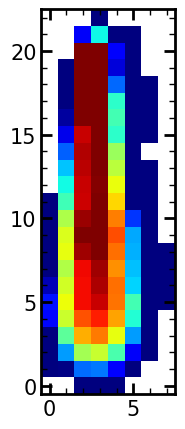

In [13]:
n_label = 20
display(DF_muons.iloc[[n_label]])

figure , axs = plt.subplots(1,1,figsize=[5,5])
# axs.imshow(list_mask_rot[n_label],  cmap = ColorMap, norm=Norm)  # 77, 1911, 2381, 2930 indices para path con elip 0.85, Sol 0.7
axs.imshow(list_datamask[n_label],  cmap = ColorMap, norm=Norm)  # 77, 1911, 2381, 2930 indices para path con elip 0.85, Sol 0.7
plt.show()


In [14]:
list_index_long_muons = []
extension = 2

for index in range(0, len(list_mask_rot)):
    size_x = list_newmatrix[index].shape[1]
    size_y = list_newmatrix[index].shape[0]
    if size_y > 20:
        # print(size_x, size_y)
        list_index_long_muons.append(list_indexs[index])

# print(list_index_long_muons)+
print('Muones largos detectados: ', len(list_index_long_muons))
print('Indices: ', list_index_long_muons)

Muones largos detectados:  30
Indices:  [20, 64, 108, 128, 194, 232, 301, 349, 386, 450, 487, 593, 697, 706, 744, 793, 869, 873, 881, 903, 925, 1053, 1091, 1100, 1141, 1145, 1160, 1167, 1175, 1276]


#### Perfil energético

25.38744638165865
Number of rows:  43


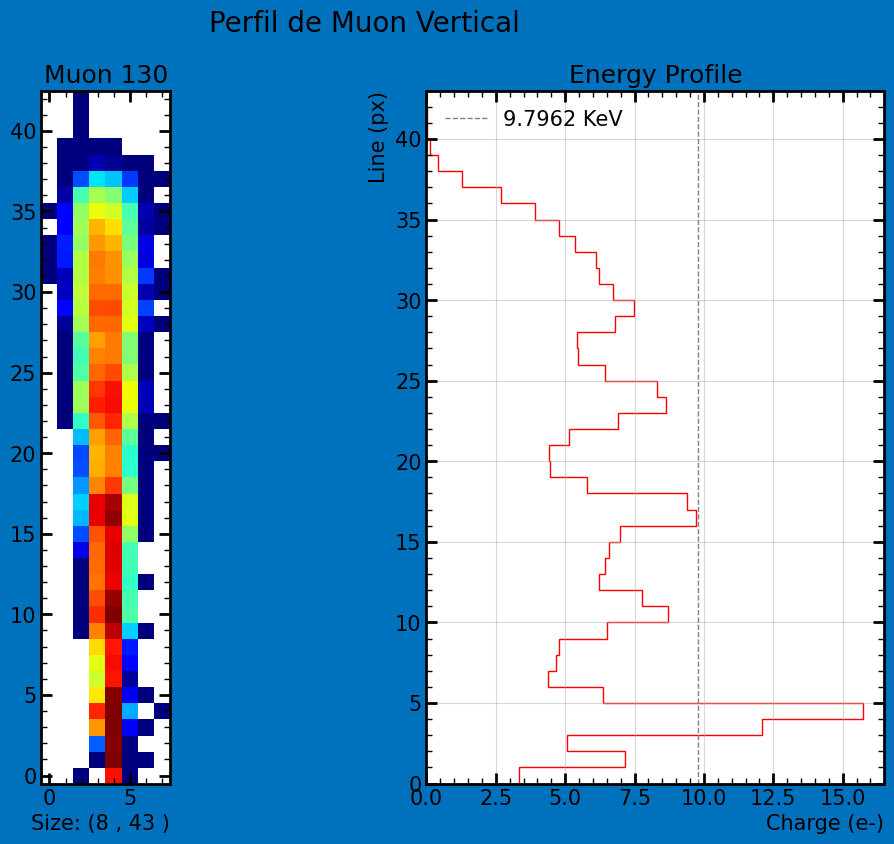

In [17]:
# list_muonlabels = [10, 15, 74, 91, 92, 112, 133, 176, 196, 256]  # Segunda revisión (están arriba)
muon_label = 130  # Se coloca directamente el label del evento
thet = DF_muons.iloc[[n_label]]['Theta (Deg)'].values[0]
print(thet)

Delta_inicial = 0
Delta_final = 0

fig, axs = plt.subplots(ncols=2, nrows=1, figsize = [13,9], facecolor = [0, 0.4470, 0.7410])
fig.suptitle('Perfil de Muon Vertical', y = 0.97, size = 20)
event = list_datamask[muon_label]
# plt.imshow(event)

size_x = event.shape[1] # tamaño en x
size_y = event.shape[0] # tamaño en y
# print(event.sum())

print('Number of rows: ', event.shape[0])
charge_verticalMuon = []
for index in range(1, size_y):
    line = event[index - 1:index][0]
    charge = line.sum()
    charge_verticalMuon.append(charge)

        
# cmap = 'plasma'
axs[0].imshow(event, cmap = ColorMap, norm = Norm)#, origin='upper')
axs[0].set_title('Muon ' + str(muon_label))
axs[0].set_xlabel('Size: (' + str(size_x) + ' , ' + str(size_y) + ' )')
# x0bar = fig.colorbar(x0, ax=axs[0])

en_cor = 4.2 /np.sin(np.radians(thet))
axs[1].stairs(charge_verticalMuon, range(0,len(charge_verticalMuon)+1),  orientation='horizontal', color = 'r')#,  hatch = '////')
axs[1].axvline(en_cor, 0, size_y+2, linestyle='--', color='gray', label = str(np.around(en_cor, 4)) +' KeV')
# axs[1].vlines(x = mean_charge, ymin = 0, ymax = len(event) - 1, color = 'k', label = 'Mean Charge \n' + str(mean_charge))

axs[1].set_ylim(0, size_y)
# axs[1].set_xlim(0, 4000)


# axs[1].set_xlabel('Charge (KeV)')
axs[1].set_xlabel('Charge (e-)')
axs[1].set_ylabel('Line (px)')
# axs[1].set_ylim(0,len(event) - 1 )
axs[1].set_title('Energy Profile')
axs[1].legend()
axs[1].grid()
plt.show()

#### XYE files

In [15]:
muon_label = 19

for n_label in list_index_long_muons:
    event = list_datamask[n_label]
    # plt.imshow(event)

    size_x = event.shape[1] # tamaño en x
    size_y = event.shape[0] # tamaño en y

    qT = 0
    list_xval = []
    list_yval = []
    list_eval = []

    for index in range(0, size_y):
        qLine = 0
        for jndex in range(0, size_x):
            if event[index][jndex]:
                # print(event[index][jndex])
                x_val, y_val, e_val = jndex,index, event[index][jndex]/0.00368
                # print(e_val)

                list_xval.append(x_val)
                list_yval.append(y_val)
                list_eval.append(e_val)
                qT +=  e_val
                qLine += e_val
        # print(qLine)
    print(qT, " e-")

    # with open(f"muons_ext2VUP/muon{n_label}.xye","w") as file:
    with open(f"muons_ext2VDOWN/muon{n_label}.xye","w") as file:
        for index in range(0, len(list_xval)):
            x_val = list_xval[index]
            y_val = list_yval[index]
            e_val = list_eval[index]
            file.write(f"{x_val} {y_val} {e_val} \n")



63209.15  e-
82401.47  e-
68514.35  e-
67020.89  e-
57140.207  e-
278463.53  e-
54801.492  e-
37558.895  e-
69361.02  e-
112871.78  e-
58500.617  e-
84251.14  e-
82061.484  e-
77643.71  e-
69104.99  e-
83094.29  e-
35790.75  e-
79063.99  e-
67090.46  e-
45786.066  e-
33795.273  e-
71308.24  e-
87010.39  e-
54815.543  e-
53148.23  e-
98816.77  e-
51536.02  e-
58341.97  e-
59666.887  e-
50048.13  e-


#### Modelo de Diff

In [22]:
CCD_depth = 725 # micras
Delta_inicial = 3    # px
Delta_final = 6     # px
Bins = 50

extension = 2
label_muon = 130
lable_line = 12
img_sigma = 0.0003  # KeV 
# print(img_sigma)

## Se checa si el muon tiene la orientación correcta
event = list_datamask[label_muon]
size_x = event.shape[1]
size_y = event.shape[0]

# lines = 0
Longitud_XY = size_y 
Longitud_linea = size_x

Z_inicial = (Delta_inicial * CCD_depth) / (Longitud_XY - Delta_final)


line = event[lable_line - 1:lable_line][0]
Carga_renglon = line.sum()
Mean_carga = np.mean(line)


Mean_in  = 0
var = 0
carga_cuadrada = 0

### Se calcula el X promedio ##
for pixel in np.arange(0, Longitud_linea, 1):
    if line[pixel]:
        element_pixel = (pixel * line[pixel]) / Carga_renglon
        Mean_in = Mean_in + element_pixel
    else:
        element_pixel = 0
    
    Mean_in = Mean_in + element_pixel

## Calcula la suma de las cargas al cuadrado ##
for pixel in np.arange(0, Longitud_linea, 1):
    if line[pixel]:
        element_pixel = line[pixel]**2
    else:
        element_pixel = 0

    carga_cuadrada = carga_cuadrada + element_pixel 

Mean_carga_cuadrada = carga_cuadrada/Longitud_linea

### Se calcula la varianza ##
for pixel in np.arange(0, Longitud_linea, 1):
    element_pixel =(1 / (Longitud_linea - 1)) * (pixel - Mean_in)**2
    var = var + element_pixel  ### COreggir la varianza con otro estimados

### Se corrige la varianza con la carga ###
var_true = var * (Mean_carga_cuadrada / (Mean_carga**2))

### Se calcula la sigma ###
sigma_in = np.sqrt(var)
# sigma_in = np.sqrt(var_true)


##Se crea un arreglo para usarlo en el plot de los datos, y se realiza el juste ##
list_xlabel = np.arange(0.5, len(line), 1)

# list_xlabel_long = np.linspace(-Longitud_linea + int(Longitud_linea/2) , Longitud_linea + int(Longitud_linea/2), Longitud_linea)

# popt, pcov = curve_fit(gaussian, list_xlabel, data_mask[0], maxfev=100000, p0 = [8000, Mean_in, sigma_in])		# Fit histogram with gaussian

print('Lonitud de la linea: ', len(line.flatten()))

## Ajuste gaussiano con ROOT ##
fgaus2 = TF1("fgauss","gaus",  0,  len(line.flatten()), 3) # TF1("nombre", "funcion escrita como en root", min, max, #parametros)
h3=TH1F("histogram", "Distribution of Line", len(line.flatten()) + 1, 0,  len(line.flatten()) )

for index in range(0, len(line)):
    if line[index] != 0:
        # print(index, line[index])
        h3.SetBinContent( index + 1, line[index])
        h3.SetBinError(index + 1, img_sigma)
        # h3.SetBinError(index + 1, 0.001)
        #print(pixel_value)

fgaus2.SetParameters(np.max(line),Mean_in,sigma_in) # Establecer parametros iniciales del fit, de manera visual es posible determinarlos como una primera aproximacion
h3.Fit(fgaus2, "RQN")

fit_const = fgaus2.GetParameters()[0]
fit_mean = fgaus2.GetParameters()[1]
fit_sigma = fgaus2.GetParameters()[2]
print('Sigma fit: ', fit_sigma, end='\n\n')

c3=TCanvas()

h3.Draw()
c3.Draw()
fgaus2.Draw("same")
# gStyle.SetOptFit(1100)
# gStyle.SetPadGridX (True)



# plt.show()

Lonitud de la linea:  8
Sigma fit:  0.5363004375113769



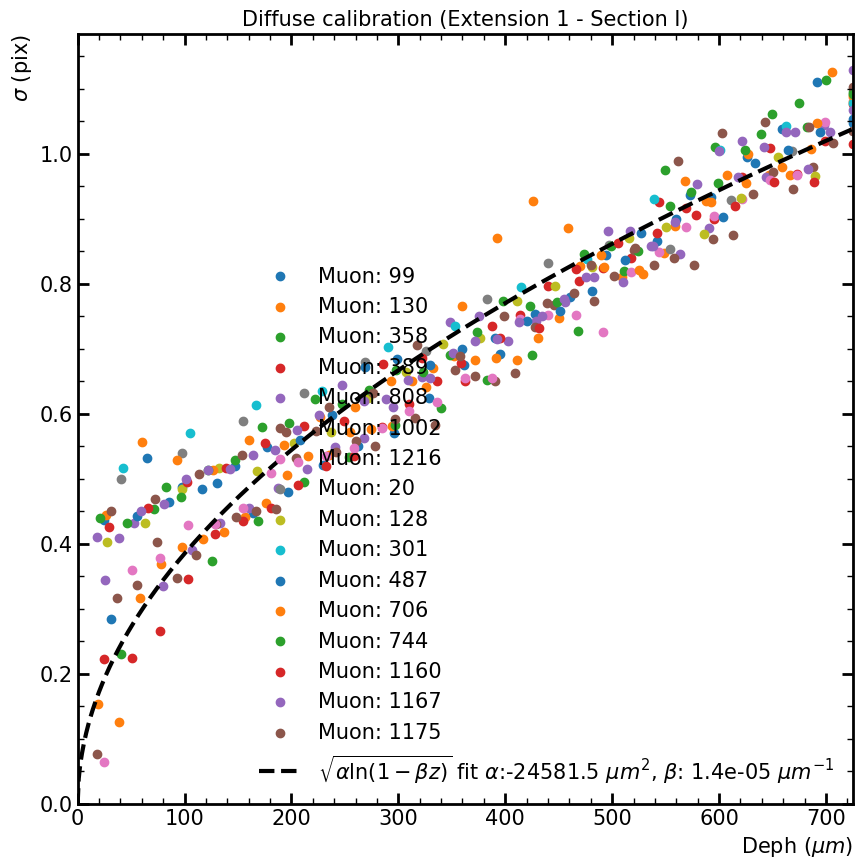

In [26]:
CCD_depth = 725 # micras
Delta_inicial = 4    # px
Delta_final = 5     # px
Bins = 50

extension = 1
label_muon = 1
img_sigma = 0.0008  # KeV 
# print(img_sigma)
fig, axs_all = plt.subplots(figsize = [10,10])

# Data for 85 to 95 
# [65, 92, 99, 112, 130, 136, 145, 149, 182, 191, 358, 389, 449, 482, 545, 550, 678, 771, 795, 808, 820, 939, 940, 947, 954, 956, 1002, 1133, 1164, 1166, 1216, 1220, 1337]


# Data for 265 to 275
# [20, 26, 64, 108, 128, 194, 232, 301, 349, 386, 450, 487, 593, 697, 706, 744, 793, 869, 873, 881, 903, 925, 1053, 1091, 1100, 1141, 1145, 1160, 1167, 1175, 1254, 1276]


list_muonlabels0 = [99, 130, 358, 389, 808, 1002, 1216] # AL 149 se disparan los valores iniciales
list_muonlabels1 = [20, 128, 301, 487, 706, 744, 1160, 1167, 1175]


list_muonlabels = list_muonlabels0 + list_muonlabels1
# list_muonlabels = list_muonlabels1


for label_muon in list_muonlabels: 
    Delta_inicial = 1    # px
    Delta_final = 5     # px
    event = list_datamask[label_muon]
    size_x = event.shape[1]
    size_y = event.shape[0]

    # lines = 0
    Longitud_XY = size_y 
    Z_inicial = (Delta_inicial * CCD_depth) / (Longitud_XY - Delta_final)
    # print('Muon: ', label_muon, ', Shape (X, Y): ', event.shape[1], event.shape[0])

    list_fitsigmas = []
    if label_muon in list_muonlabels1:
        Delta_inicial = Delta_final
        Delta_final = Delta_inicial


    for lable_line in range(Delta_inicial, size_y - Delta_final):
        line = event[lable_line - 1:lable_line][0]
        Carga_renglon = line.sum()
        Mean_carga = np.mean(line)
        Longitud_linea = len(line)


        Mean_in  = 0
        var = 0
        carga_cuadrada = 0

        ### Se calcula el X promedio ##
        for pixel in range(0, Longitud_linea):
            if line[pixel]:
                element_pixel = (pixel * line[pixel]) / Carga_renglon
                Mean_in = Mean_in + element_pixel
            else:
                element_pixel = 0
            
            Mean_in = Mean_in + element_pixel

        ## Calcula la suma de las cargas al cuadrado ##
        for pixel in np.arange(0, Longitud_linea, 1):
            if line[pixel]:
                element_pixel = line[pixel]**2
            else:
                element_pixel = 0

            carga_cuadrada = carga_cuadrada + element_pixel 

        Mean_carga_cuadrada = carga_cuadrada/Longitud_linea

        ### Se calcula la varianza ##
        for pixel in np.arange(0, Longitud_linea, 1):
            if line[pixel]:
                element_pixel =(1 / (Longitud_linea - 1)) * (pixel - Mean_in)**2 * line[pixel]
                var = var + element_pixel  ### COreggir la varianza con otro estimados

        ### Se corrige la varianza con la carga ###
        # var_true = var * (Mean_carga_cuadrada / (Mean_carga**2))
        var_true = var / Carga_renglon

        ### Se calcula la sigma ###
        sigma_in = np.sqrt(var_true)
        # print(sigma_in)
        # sigma_in = np.sqrt(var_true)


        ##Se crea un arreglo para usarlo en el plot de los datos, y se realiza el juste ##
        list_xlabel = np.arange(0.5, len(line), 1)


        ## Ajuste gaussiano con ROOT ##
        fgaus2 = TF1("fgauss","gaus",  0,  len(line.flatten()), 3) # TF1("nombre", "funcion escrita como en root", min, max, #parametros)
        h3=TH1F("histogram", "Distribution of Line", len(line.flatten()) + 1, 0,  len(line.flatten()) )

        for index in range(0, len(line)):
            if line[index] != 0:
                # print(index, line[index])
                h3.SetBinContent( index + 1, line[index])
                h3.SetBinError(index + 1, img_sigma)
                # h3.SetBinError(index + 1, 0.001)
                #print(pixel_value)

        fgaus2.SetParameters(np.max(line),Mean_in,sigma_in) # Establecer parametros iniciales del fit, de manera visual es posible determinarlos como una primera aproximacion
        h3.Fit(fgaus2, "RQN")

        fit_const = fgaus2.GetParameters()[0]
        fit_mean = fgaus2.GetParameters()[1]
        fit_sigma = fgaus2.GetParameters()[2]


        # fit_sigma = sigma_in
        # print('Sigma fit: ', fit_sigma)
        list_fitsigmas.append(fit_sigma)

        del h3

    list_deep = []
    list_xlabel_sigmas = np.linspace(Z_inicial, CCD_depth, len(list_fitsigmas))
    for deep in list_xlabel_sigmas:
        list_deep.append(deep)

    if label_muon in list_muonlabels1:
    #     # print('Gola', list_fitsigmas[0], list_fitsigmas[-1])
        list_fitsigmas.reverse()
    #     # print('Agios', list_fitsigmas[0], list_fitsigmas[-1], end='\n\n')

    axs_all.scatter(list_deep, list_fitsigmas, label = 'Muon: ' + str(label_muon))
    # axs_all.scatter(list_deep, list_fitsigmas)


def diffution_curve(z, alpha, beta):
    return np.sqrt((alpha * np.log(1 - (beta * z))))

fit_range = np.arange(0, 725)
Label = r'$\sqrt{\alpha \ln(1 - \beta z)}$ fit $\alpha$:' + str(np.around(fit_alpha, 1)) + r' $\mu m^{2}$, $\beta$: ' + str(np.around(fit_beta, 6)) + r' $\mu m^{-1}$'

# axs_all.plot(fit_range, diffution_curve(fit_range, alpha=-200, beta=0.001) / 15, '--r', linewidth = 3)
axs_all.plot(fit_range, diffution_curve(fit_range, alpha=fit_alpha, beta=fit_beta)/15, '--k', linewidth = 3, label= Label)
# axs_all.plot(fit_range, diffution_curve(fit_range, alpha=-292.4325743170209, beta=3.990904646095944e-06), '--c', linewidth = 2, label='Fit CONNIE')

axs_all.set_title('Diffuse calibration (Extension 1 - Section I)', size = 15)#, y=0.92)}
axs_all.set_ylabel(r'$\sigma$ (pix)')
axs_all.set_xlabel(r'Deph ($\mu m$)')
axs_all.set_ylim(0, )
axs_all.set_xlim(0, 725)
axs_all.legend()
axs_all.grid
plt.show()

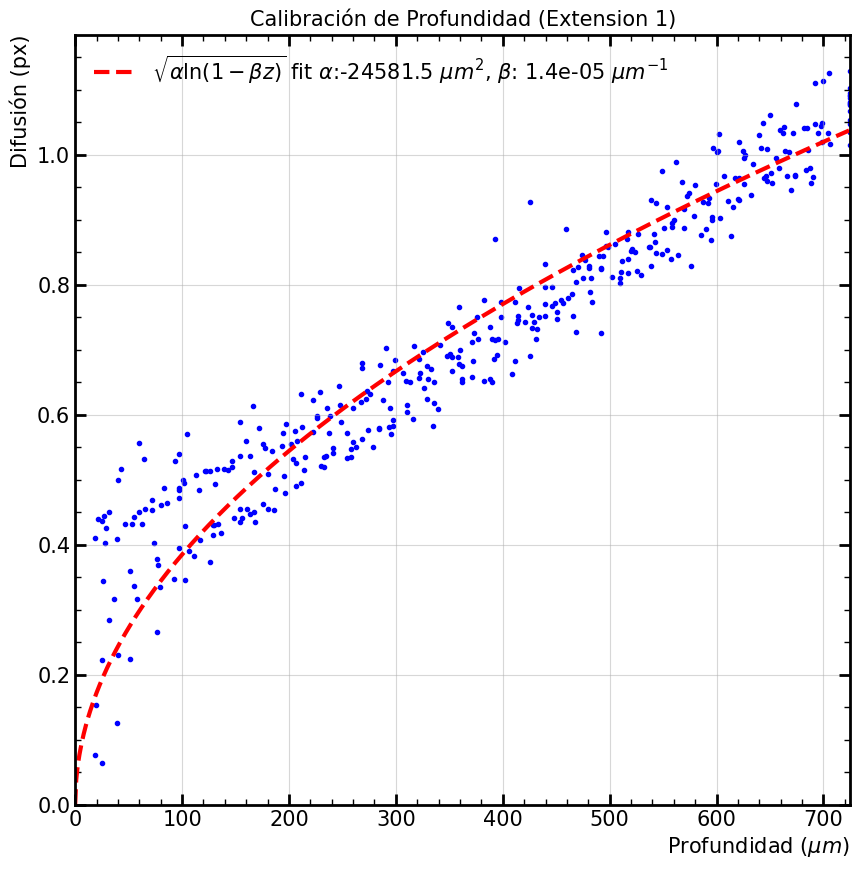

In [27]:
img_sigma = 0.0008  # KeV 
# print(img_sigma)
fig, axs_all = plt.subplots(figsize = [10,10])

# list_muonlabels = [256, 257, 258]

list_all_sigmas = []
list_all_deeps = []

for label_muon in list_muonlabels: 
    Delta_inicial = 1    # px
    Delta_final = 5     # px
    event = list_datamask[label_muon]
    size_x = event.shape[1]
    size_y = event.shape[0]

    # lines = 0
    Longitud_XY = size_y 
    Z_inicial = (Delta_inicial * CCD_depth) / (Longitud_XY - Delta_final)
    # print('Muon: ', label_muon, ', Shape (X, Y): ', event.shape[1], event.shape[0])

    list_fitsigmas = []
    if label_muon in list_muonlabels1:
        Delta_inicial = Delta_final
        Delta_final = Delta_inicial

    for lable_line in range(Delta_inicial, size_y - Delta_final):
        line = event[lable_line - 1:lable_line][0]
        Carga_renglon = line.sum()
        Mean_carga = np.mean(line)
        Longitud_linea = len(line)


        Mean_in  = 0
        var = 0
        carga_cuadrada = 0

        ### Se calcula el X promedio ##
        for pixel in range(0, Longitud_linea):
            if line[pixel]:
                element_pixel = (pixel * line[pixel]) / Carga_renglon
                Mean_in = Mean_in + element_pixel
            else:
                element_pixel = 0
            
            Mean_in = Mean_in + element_pixel

        ## Calcula la suma de las cargas al cuadrado ##
        for pixel in np.arange(0, Longitud_linea, 1):
            if line[pixel]:
                element_pixel = line[pixel]**2
            else:
                element_pixel = 0

            carga_cuadrada = carga_cuadrada + element_pixel 

        Mean_carga_cuadrada = carga_cuadrada/Longitud_linea

        ### Se calcula la varianza ##
        for pixel in np.arange(0, Longitud_linea, 1):
            if line[pixel]:
                element_pixel =(1 / (Longitud_linea - 1)) * (pixel - Mean_in)**2 * line[pixel]
                var = var + element_pixel  ### COreggir la varianza con otro estimados

        ### Se corrige la varianza con la carga ###
        # var_true = var * (Mean_carga_cuadrada / (Mean_carga**2))
        var_true = var / Carga_renglon

        ### Se calcula la sigma ###
        sigma_in = np.sqrt(var)
        # print(sigma_in)
        # sigma_in = np.sqrt(var_true)


        ##Se crea un arreglo para usarlo en el plot de los datos, y se realiza el juste ##
        list_xlabel = np.arange(0.5, len(line), 1)


        ## Ajuste gaussiano con ROOT ##
        fgaus2 = TF1("fgauss","gaus",  0,  len(line.flatten()), 3) # TF1("nombre", "funcion escrita como en root", min, max, #parametros)
        h3=TH1F("histogram", "Distribution of Line", len(line.flatten()) + 1, 0,  len(line.flatten()) )

        for index in range(0, len(line)):
            if line[index] != 0:
                # print(index, line[index])
                h3.SetBinContent( index + 1, line[index])
                h3.SetBinError(index + 1, img_sigma)
                # h3.SetBinError(index + 1, 0.001)
                #print(pixel_value)

        fgaus2.SetParameters(np.max(line),Mean_in,sigma_in) # Establecer parametros iniciales del fit, de manera visual es posible determinarlos como una primera aproximacion
        h3.Fit(fgaus2, "RQN")

        fit_const = fgaus2.GetParameters()[0]
        fit_mean = fgaus2.GetParameters()[1]
        fit_sigma = fgaus2.GetParameters()[2]


        # fit_sigma = sigma_in
        # print('Sigma fit: ', fit_sigma)
        list_fitsigmas.append(fit_sigma)

        del h3

    list_deep = []
    list_xlabel_sigmas = np.linspace(Z_inicial, CCD_depth, len(list_fitsigmas))
    for deep in list_xlabel_sigmas:
        list_deep.append(deep)

    if label_muon in list_muonlabels1:
        # print('Gola', list_fitsigmas[0], list_fitsigmas[-1])
        list_fitsigmas.reverse()
        # print('Agios', list_fitsigmas[0], list_fitsigmas[-1], end='\n\n')
        
    for index in range(0, len(list_fitsigmas)):
        list_all_sigmas.append(list_fitsigmas[index])
        list_all_deeps.append(list_deep[index])

    # axs_all.scatter(list_deep, list_fitsigmas, marker='2', label = 'Muon: ' + str(label_muon))
del list_fitsigmas
del list_deep


fit_range = np.arange(0, 725)



axs_all.scatter(list_all_deeps, list_all_sigmas, marker='.', facecolor = 'b')

def diffution_curve(x, alpha, beta):
    return np.sqrt((alpha * np.log(1 - (beta * x))))

# popt_DM, _ = curve_fit(diffution_curve, list_all_deeps, list_all_sigmas, maxfev=100000, p0= [1, 1])
# dict_diffution_model = {'Alpha' : popt_DM[0], 'Beta' : popt_DM[1]}
# print('Alpha: ', dict_diffution_model['Alpha'], ' Beta: ', dict_diffution_model['Beta'])



axs_all.plot(fit_range, diffution_curve(fit_range, alpha=fit_alpha, beta=fit_beta)/15, '--r', linewidth = 3, label= Label)
# axs_all.plot(fit_range, diffution_curve(fit_range, -611, 0.00045)/15, '--r', linewidth = 3)

axs_all.set_title('Calibración de Profundidad (Extension 1)', size = 15)#, y=0.92)}
axs_all.set_ylabel(r'Difusión (px)')
axs_all.set_xlabel(r'Profundidad ($\mu m$)')
axs_all.set_ylim(0,)
axs_all.set_xlim(0, 725)
axs_all.legend()
axs_all.grid()
plt.show()

In [28]:
list_all_sigmas = []
list_all_deeps = []

for label_muon in list_muonlabels: 
    Delta_inicial = 1    # px
    Delta_final = 5     # px
    event = list_datamask[label_muon]
    size_x = event.shape[1]
    size_y = event.shape[0]

    # lines = 0
    Longitud_XY = size_y 
    Z_inicial = (Delta_inicial * CCD_depth) / (Longitud_XY - Delta_final)
    # print('Muon: ', label_muon, ', Shape (X, Y): ', event.shape[1], event.shape[0])

    list_fitsigmas = []
    if label_muon in list_muonlabels1:
        Delta_inicial = Delta_final
        Delta_final = Delta_inicial

    for lable_line in range(Delta_inicial, size_y - Delta_final):
        line = event[lable_line - 1:lable_line][0]
        Carga_renglon = line.sum()
        Mean_carga = np.mean(line)
        Longitud_linea = len(line)


        Mean_in  = 0
        var = 0
        carga_cuadrada = 0

        ### Se calcula el X promedio ##
        for pixel in range(0, Longitud_linea):
            if line[pixel]:
                element_pixel = (pixel * line[pixel]) / Carga_renglon
                Mean_in = Mean_in + element_pixel
            else:
                element_pixel = 0
            
            Mean_in = Mean_in + element_pixel

        ## Calcula la suma de las cargas al cuadrado ##
        for pixel in np.arange(0, Longitud_linea, 1):
            if line[pixel]:
                element_pixel = line[pixel]**2
            else:
                element_pixel = 0

            carga_cuadrada = carga_cuadrada + element_pixel 

        Mean_carga_cuadrada = carga_cuadrada/Longitud_linea

        ### Se calcula la varianza ##
        for pixel in np.arange(0, Longitud_linea, 1):
            if line[pixel]:
                element_pixel =(1 / (Longitud_linea - 1)) * (pixel - Mean_in)**2 * line[pixel]
                var = var + element_pixel  ### COreggir la varianza con otro estimados

        ### Se corrige la varianza con la carga ###
        # var_true = var * (Mean_carga_cuadrada / (Mean_carga**2))
        var_true = var / Carga_renglon

        ### Se calcula la sigma ###
        sigma_in = np.sqrt(var)
        # print(sigma_in)
        # sigma_in = np.sqrt(var_true)


        ##Se crea un arreglo para usarlo en el plot de los datos, y se realiza el juste ##
        list_xlabel = np.arange(0.5, len(line), 1)


        ## Ajuste gaussiano con ROOT ##
        fgaus2 = TF1("fgauss","gaus",  0,  len(line.flatten()), 3) # TF1("nombre", "funcion escrita como en root", min, max, #parametros)
        h3=TH1F("histogram", "Distribution of Line", len(line.flatten()) + 1, 0,  len(line.flatten()) )

        for index in range(0, len(line)):
            if line[index] != 0:
                # print(index, line[index])
                h3.SetBinContent( index + 1, line[index])
                h3.SetBinError(index + 1, img_sigma)
                # h3.SetBinError(index + 1, 0.001)
                #print(pixel_value)

        fgaus2.SetParameters(np.max(line),Mean_in,sigma_in) # Establecer parametros iniciales del fit, de manera visual es posible determinarlos como una primera aproximacion
        h3.Fit(fgaus2, "RQN")

        fit_const = fgaus2.GetParameters()[0]
        fit_mean = fgaus2.GetParameters()[1]
        fit_sigma = fgaus2.GetParameters()[2]


        # fit_sigma = sigma_in
        # print('Sigma fit: ', fit_sigma)
        list_fitsigmas.append(fit_sigma)

        del h3

    list_deep = []
    list_xlabel_sigmas = np.linspace(Z_inicial, CCD_depth, len(list_fitsigmas))
    for deep in list_xlabel_sigmas:
        list_deep.append(deep)

    if label_muon in list_muonlabels1:
        # print('Gola', list_fitsigmas[0], list_fitsigmas[-1])
        list_fitsigmas.reverse()
        # print('Agios', list_fitsigmas[0], list_fitsigmas[-1], end='\n\n')

    for index in range(0, len(list_fitsigmas)):
        list_all_sigmas.append(list_fitsigmas[index])
        list_all_deeps.append(list_deep[index])

    # axs_all.scatter(list_deep, list_fitsigmas, marker='2', label = 'Muon: ' + str(label_muon))
del list_fitsigmas
del list_deep



# fit_range = np.arange(0, 900)
# axs_all.scatter(list_all_deeps, list_all_sigmas, marker='2')
 
h_model = TGraph(len(list_all_sigmas), np.array(list_all_deeps),np.array(list_all_sigmas))
h_model.SetMarkerStyle(2) # Set marker style (e.g., solid circle)
h_model.SetTitle("Modelo de dif. (Extensión 2- Muones Verticales)")
h_model.GetXaxis().SetTitle("Profundidad (micras)")
h_model.GetYaxis().SetTitle("Anchura (micras)")
h_model.SetStats(0)
h_model.GetXaxis().SetRangeUser(0, 725)
h_model.GetYaxis().SetRangeUser(0, 1.4)



Range_fit = [0, 725]
diff_curve = TF1("diff_curve", "sqrt(([0] * log(1 - [1]*x)))/15", Range_fit[0], Range_fit[1], 2) #np.sqrt(np.abs(alpha * np.log(1 - (beta * z))))

diff_curve.SetParameters(-200, 0.00001) # Establecer parametros iniciales del fit, de manera visual es posible determinarlos como una primera aproximacion
h_model.Fit(diff_curve, "RNQ")

fit_alpha = diff_curve.GetParameters()[0]
fit_beta = diff_curve.GetParameters()[1]
chi2 = diff_curve.GetChisquare()
ndf = diff_curve.GetNDF()
prob = diff_curve.GetProb()

fit_alpha_err = diff_curve.GetParErrors()[0]
fit_beta_err = diff_curve.GetParErrors()[1]

print('Alpha: ', fit_alpha, '+- ', fit_alpha_err) 
print('Beta: ', fit_beta,  '+- ', fit_beta_err)
print('Chi2/ndf: ', chi2, '/', ndf)
print('Prob: ', prob)

c3=TCanvas("","", 1000, 600)
h_model.Draw("AP same")
diff_curve.Draw("same")
c3.Draw()

leg = TLegend(0.1,0.7,0.48,0.9)
leg.AddEntry(diff_curve, r"\sqrt{\alpha \log(1 - \beta z)} fit: \alpha= " + str(np.around(fit_alpha, 3)) + r" \mu m^2, \beta= " + str(np.around(fit_beta, 6)) + " \mu m^{-1}", "L")
leg.Draw()

Alpha:  -12118.340781328252 +-  3946.135893628133
Beta:  2.6908507179649492e-05 +-  8.97767248124544e-06
Chi2/ndf:  1.9877903408258168 / 390
Prob:  1.0


In [29]:
from array import array

spread_array = array('f', [-9999])
deep_array = array('f', [-9999])

location_file = './'
file_root_name = 'tree_DiffusionMod_Ext2_Vert.root'
file = TFile.Open(location_file  + file_root_name, "RECREATE")
tree = TTree('tree', 'tree')

tree.Branch('sprd', spread_array, 'sprd/F')
tree.Branch('deep', deep_array, 'deep/F')

for i in range(0, len(list_all_sigmas)):
    spread_array[0] = list_all_sigmas[i]
    deep_array[0] = list_all_deeps[i]
    
    tree.Fill()

tree.Write()
file.Close()

### Muones Horizontales

#### DataFrame y visualización

In [26]:
### Se crea el dataframe y se selecciona un rango de datos ###
Ext = 2
DF_muons, list_datamask = DataFrame_muons(data_histogram, extension=Ext, units=1)
# display(DF_muons[450:500])
list_newmatrix = []
list_indexs =[]
#
# range_in_phi = DF_muons[DF_muons['Phi (Deg)'].between(0, 5)]    # Horizontales derecha
# range_in_phi = DF_muons[DF_muons['Phi (Deg)'].between(355, 360)]

range_in_phi = DF_muons[DF_muons['Phi (Deg)'].between(175, 185)] # Horizontales izquierda

for index in range_in_phi.index:
    # print(index)
    list_newmatrix.append(list_datamask[index])
    list_indexs.append(index)

print(list_indexs)
list_phi_ext1 = data_histogram['extension_' + str(Ext)]['phi']
list_mask_rot = []

list_listsnxny = []

for index in list_indexs[:]:
    datamask = list_datamask[index]
    ylen, xlen = datamask.shape
    list_nxny = []

    data_mask_zeros = np.empty((ylen + 90, xlen+50))
    data_mask_zeros[:] = 0
    ylen_zeros, xlen_zeros = data_mask_zeros.shape
    # print(data_mask_zeros.shape)
    
    ### Angle rot ##
    phi_rot = np.pi/2 - list_phi_ext1[index]
    # print(phi_rot, phi_rot + list_phi_ext1[index])

    # print('shape original: ', xlen, ylen)
    # print('shape zeros: ', xlen_zeros, ylen_zeros)

    # for y_bin in range(0, ylen):
    #     for x_bin in range(0, xlen):
    #         if datamask[y_bin][x_bin] != 0:
    #             nx, ny = pixel_rot(x_bin=x_bin, x0=0, y_bin=y_bin, y0=0, theta= phi_rot)
    #             list_nxny.append((nx + 200, ny))
    #             # print(nx, ny)
    #             data_mask_zeros[ny][nx+200] = datamask[y_bin][x_bin]

    # list_listsnxny.append(list_nxny)
    # label_img, nlabels_img = sk.measure.label(data_mask_zeros > 0, connectivity=2, return_num=True)
    # loc = nd.find_objects(label_img == 1)[0]
    # mask_rot = np.invert(label_img==1)
    # # data_mask_rot = ma.masked_array(data_mask_zeros, mask_rot)
    # data_mask_rot = ma.masked_array(data_mask_zeros[loc[0].start:loc[0].stop, loc[1].start:loc[1].stop], mask_rot[loc[0].start:loc[0].stop, loc[1].start:loc[1].stop])

    # list_mask_rot.append(data_mask_rot)
    # print('Shape rot: ', data_mask_rot.shape[1], data_mask_rot.shape[0])
    
    # plt.imshow(data_mask_rot)
    # plt.show()

# print(list_mask_rot)
#     

[5, 43, 47, 50, 81, 96, 104, 170, 192, 209, 219, 228, 238, 241, 246, 252, 265, 285, 313, 347, 372, 379, 388, 399, 411, 433, 442, 524, 565, 568, 591, 701, 723, 766, 768, 785, 786, 821, 835, 838, 839, 841, 846, 859, 860, 879, 889, 899, 909, 921, 945, 957, 965, 986, 997, 1016, 1043, 1069, 1073, 1080, 1086, 1116, 1131, 1137, 1153, 1154, 1157, 1206, 1225, 1247, 1248, 1330]


,date_run,Gain (ADU/e-),Solidity,Elipticity,Theta (Deg),Phi (Deg),Charge (e-),l (cm),dEdL (KeV/cm)
Muon ID,,,,,,,,,
965,ENE2025,220.3055,0.755784,0.873253,47.906578,181.005592,6850.431691,0.108154,2330.900919


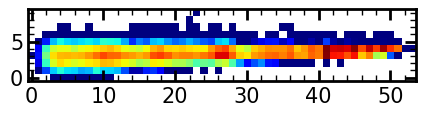

,date_run,Gain (ADU/e-),Solidity,Elipticity,Theta (Deg),Phi (Deg),Charge (e-),l (cm),dEdL (KeV/cm)
Muon ID,,,,,,,,,
219,ENE2024,206.690861,0.860987,0.900774,43.562681,179.844175,8187.577621,0.100052,3011.45302


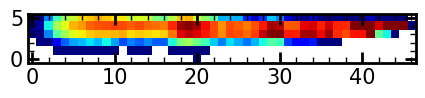

In [27]:
n_label = 965
display(DF_muons.iloc[[n_label]])

figure , axs = plt.subplots(1,1,figsize=[5,5])
# axs.imshow(list_mask_rot[n_label],  cmap = ColorMap, norm=Norm)  
axs.imshow(list_datamask[n_label],  cmap = ColorMap, norm=Norm)
plt.show()

n_label = 219
display(DF_muons.iloc[[n_label]])

figure , axs = plt.subplots(1,1,figsize=[5,5])
# axs.imshow(list_mask_rot[n_label],  cmap = ColorMap, norm=Norm)  
axs.imshow(list_datamask[n_label],  cmap = ColorMap, norm=Norm)
plt.show()


Numper of rows:  6
Long of line:  3


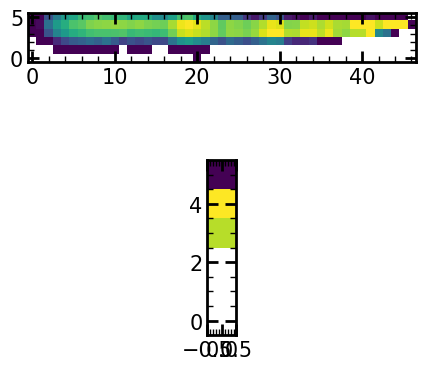

In [28]:
figure , axs = plt.subplots(2,1,figsize=[5,5])

label_muon = n_label
label_line = 40
muon = list_datamask[label_muon]
print('Numper of rows: ', muon.shape[0])
line = muon[:, label_line: label_line + 1]
# line = list_mask_rot[label_muon][label_line - 1:label_line][0]

n_longline = 0
for pixel in line:
    if pixel[0] != 0:
        # print(pixel)
        n_longline += 1

print('Long of line: ', n_longline)

# axs[0].imshow(list_mask_rot[label_muon], norm = Norm)
# axs[1].imshow(list_mask_rot[label_muon][label_line - 1:label_line], norm = Norm)

axs[0].imshow(muon, norm = Norm)
axs[1].imshow(muon[:, label_line: label_line + 1], norm = Norm)
plt.show()

In [29]:
list_index_long_muons = []
extension = 2

for index in range(0, len(list_newmatrix)):
    size_x = list_newmatrix[index].shape[1]
    # size_y = list_datamask[index].shape[0]
    if size_x > 20:
        # print(size_x, size_y)
        list_index_long_muons.append(list_indexs[index])

# print(list_index_long_muons)+
print('Muones largos detectados: ', len(list_index_long_muons))
print('Indices: ', list_index_long_muons)

Muones largos detectados:  67
Indices:  [5, 43, 47, 50, 81, 96, 104, 170, 209, 219, 228, 241, 246, 252, 265, 285, 313, 347, 372, 379, 388, 399, 411, 433, 442, 524, 565, 568, 701, 723, 766, 768, 785, 786, 821, 835, 838, 839, 841, 846, 859, 860, 879, 889, 899, 909, 921, 945, 965, 986, 997, 1016, 1043, 1069, 1073, 1080, 1086, 1116, 1131, 1153, 1154, 1157, 1206, 1225, 1247, 1248, 1330]


#### Perfil energético

50.73087979068733
Number of rows:  8


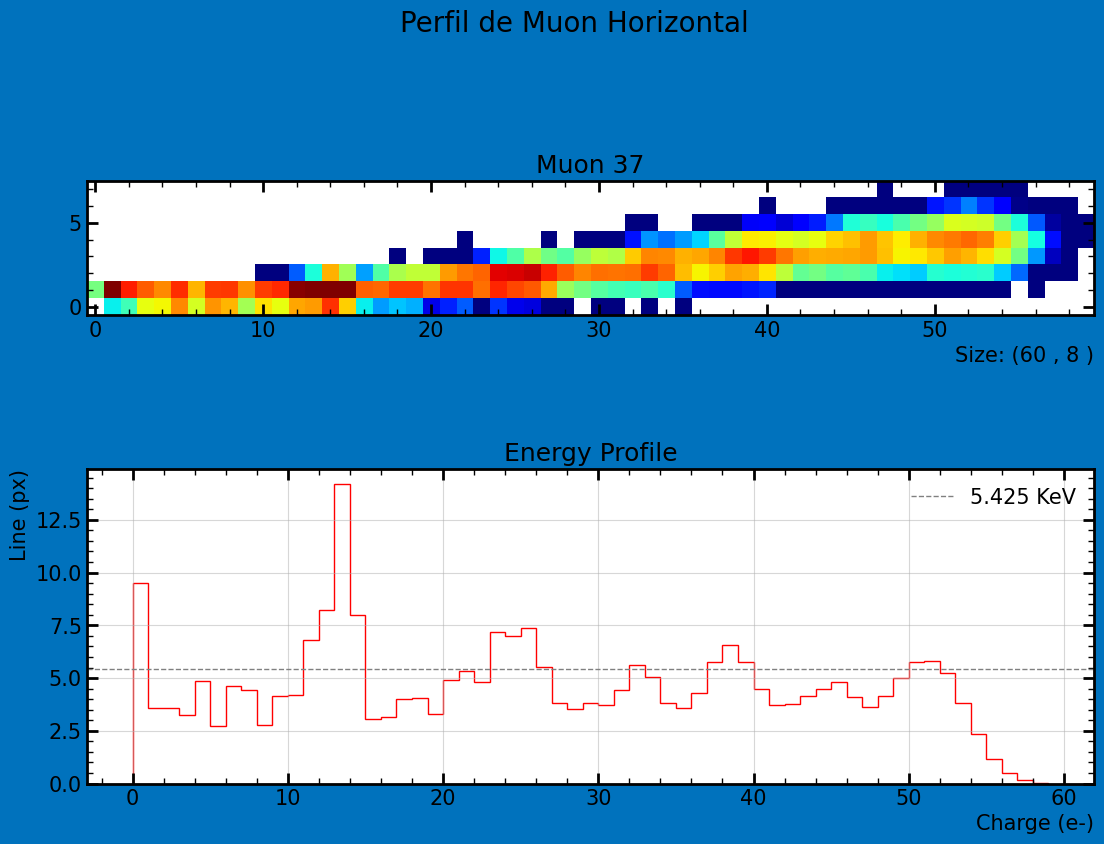

In [27]:
muon_label = 37  # Se coloca directamente el label del evento
thet = DF_muons.iloc[[n_label]]['Theta (Deg)'].values[0]
print(thet)

Delta_inicial = 0
Delta_final = 0
extension = 1

fig, axs = plt.subplots(ncols=1, nrows=2, figsize = [13,9], facecolor = [0, 0.4470, 0.7410])
fig.suptitle('Perfil de Muon Horizontal', y = 0.97, size = 20)
event = list_datamask[muon_label]
# plt.imshow(event)

size_x = event.shape[1] # tamaño en x
size_y = event.shape[0] # tamaño en y
# print(event.sum())

print('Number of rows: ', event.shape[0])
charge_horizontalMuon = []
for index in range(1, size_x):
    line = event[:, index: index + 1]
    charge = line.sum()
    charge_horizontalMuon.append(charge)

        
# cmap = 'plasma'
axs[0].imshow(event, cmap = ColorMap, norm = Norm)#, origin='upper')
axs[0].set_title('Muon ' + str(muon_label))
axs[0].set_xlabel('Size: (' + str(size_x) + ' , ' + str(size_y) + ' )')
# x0bar = fig.colorbar(x0, ax=axs[0])

en_cor = 4.2 /np.sin(np.radians(thet))
axs[1].stairs(charge_horizontalMuon, range(0,len(charge_horizontalMuon)+1),  orientation='vertical', color = 'r')#,  hatch = '////')
axs[1].axhline(en_cor, 0, size_x+2, linestyle='--', color='gray', label = str(np.around(en_cor, 3)) +  ' KeV')
# axs[1].vlines(x = mean_charge, ymin = 0, ymax = len(event) - 1, color = 'k', label = 'Mean Charge \n' + str(mean_charge))

# axs[1].set_ylim(0, size_x)
# axs[1].set_xlim(0, 4000)


# axs[1].set_xlabel('Charge (KeV)')
axs[1].set_xlabel('Charge (e-)')
axs[1].set_ylabel('Line (px)')
# axs[1].set_ylim(0,len(event) - 1 )
axs[1].set_title('Energy Profile')
axs[1].legend()
axs[1].grid()
plt.show()

#### XYE files

In [30]:
muon_label = 19

for n_label in list_index_long_muons:
    event = list_datamask[n_label]
    # plt.imshow(event)

    size_x = event.shape[1] # tamaño en x
    size_y = event.shape[0] # tamaño en y

    qT = 0
    list_xval = []
    list_yval = []
    list_eval = []

    for index in range(0, size_y):
        qLine = 0
        for jndex in range(0, size_x):
            if event[index][jndex]:
                # print(event[index][jndex])
                x_val, y_val, e_val = jndex,index, event[index][jndex]/0.00368
                # print(e_val)

                list_xval.append(x_val)
                list_yval.append(y_val)
                list_eval.append(e_val)
                qT +=  e_val
                qLine += e_val
        # print(qLine)
    print(qT, " e-")

    # with open(f"muons_ext2HRIGHT1/muon{n_label}.xye","w") as file:
    # with open(f"muons_ext2HRIGHT2/muon{n_label}.xye","w") as file:
    with open(f"muons_ext2HLEFT/muon{n_label}.xye","w") as file:
        for index in range(0, len(list_xval)):
            x_val = list_xval[index]
            y_val = list_yval[index]
            e_val = list_eval[index]
            file.write(f"{x_val} {y_val} {e_val} \n")



75027.12  e-
70429.47  e-
56837.887  e-
56998.32  e-
44922.605  e-
32872.797  e-
101791.3  e-
68640.37  e-
66979.96  e-
81875.75  e-
81274.51  e-
99791.21  e-
68032.5  e-
63919.094  e-
69605.75  e-
38541.215  e-
45918.477  e-
93107.25  e-
57791.613  e-
76337.625  e-
114404.27  e-
58769.246  e-
104756.27  e-
86759.06  e-
54823.24  e-
61152.445  e-
61672.043  e-
32568.594  e-
83667.4  e-
82436.336  e-
80897.19  e-
206577.08  e-
73343.33  e-
57238.805  e-
36598.137  e-
103491.66  e-
115685.78  e-
93710.82  e-
50398.17  e-
56885.85  e-
67418.76  e-
39995.48  e-
31999.764  e-
81884.88  e-
60200.676  e-
58889.953  e-
69341.98  e-
180870.05  e-
68504.28  e-
78568.72  e-
52741.67  e-
54025.07  e-
66411.69  e-
63190.06  e-
67438.54  e-
87000.805  e-
71489.555  e-
82066.12  e-
78697.73  e-
66787.11  e-
132767.39  e-
43569.285  e-
65680.3  e-
66941.0  e-
54096.273  e-
54506.58  e-
82130.45  e-


#### Modelo de dif.

In [42]:
CCD_depth = 725 # micras
Delta_inicial = 3    # px
Delta_final = 6     # px
Bins = 50

extension = 1
label_muon = 36
lable_line = 12
img_sigma = 0.0003  # KeV 
# print(img_sigma)

## Se checa si el muon tiene la orientación correcta
event = list_datamask[label_muon]
size_x = event.shape[1]
size_y = event.shape[0]

# lines = 0
Longitud_XY = size_x 
Longitud_linea = size_y

Z_inicial = (Delta_inicial * CCD_depth) / (Longitud_XY - Delta_final)


line = event[:, lable_line: lable_line + 1]
Carga_renglon = line.sum()
Mean_carga = np.mean(line)
# print(Carga_renglon, Mean_carga, len(line))


Mean_in  = 0
var = 0
carga_cuadrada = 0

### Se calcula el X promedio ##
for pixel in range(0, Longitud_linea, 1):
    if line[pixel][0]:
        element_pixel = (pixel * line[pixel][0]) / Carga_renglon
        Mean_in = Mean_in + element_pixel
    else:
        element_pixel = 0
    
    Mean_in = Mean_in + element_pixel

## Calcula la suma de las cargas al cuadrado ##
for pixel in range(0, Longitud_linea, 1):
    if line[pixel][0]:
        # print(line[pixel])
        element_pixel = line[pixel][0]**2
    else:
        element_pixel = 0

    carga_cuadrada = carga_cuadrada + element_pixel 

Mean_carga_cuadrada = carga_cuadrada/Longitud_linea

### Se calcula la varianza ##
for pixel in range(0, Longitud_linea, 1):
    element_pixel =(1 / (Longitud_linea - 1)) * (pixel - Mean_in)**2
    var = var + element_pixel  ### COreggir la varianza con otro estimados

### Se corrige la varianza con la carga ###
var_true = var * (Mean_carga_cuadrada / (Mean_carga**2))

### Se calcula la sigma ###
sigma_in = np.sqrt(var)
# sigma_in = np.sqrt(var_true)


##Se crea un arreglo para usarlo en el plot de los datos, y se realiza el juste ##
list_xlabel = np.arange(0.5, len(line), 1)
print('Lonitud de la linea: ', len(line))

## Ajuste gaussiano con ROOT ##
fgaus2 = TF1("fgauss","gaus",  0,  len(line), 3) # TF1("nombre", "funcion escrita como en root", min, max, #parametros)
h3=TH1F("histogram", "Distribution of Line", len(line) + 1, 0,  len(line) )

for index in range(0, len(line)):
    if line[index][0] != 0:
        # print(index, line[index])
        h3.SetBinContent( index + 1, line[index][0])
        h3.SetBinError(index + 1, img_sigma)
        # h3.SetBinError(index + 1, 0.001)
        #print(pixel_value)

fgaus2.SetParameters(np.max(line),Mean_in,sigma_in) # Establecer parametros iniciales del fit, de manera visual es posible determinarlos como una primera aproximacion
h3.Fit(fgaus2, "RQN")

fit_const = fgaus2.GetParameters()[0]
fit_mean = fgaus2.GetParameters()[1]
fit_sigma = fgaus2.GetParameters()[2]
print('Sigma fit: ', fit_sigma, end='\n\n')

c3=TCanvas()

h3.Draw()
c3.Draw()
fgaus2.Draw("same")

Lonitud de la linea:  46
Sigma fit:  1.2552080458794823



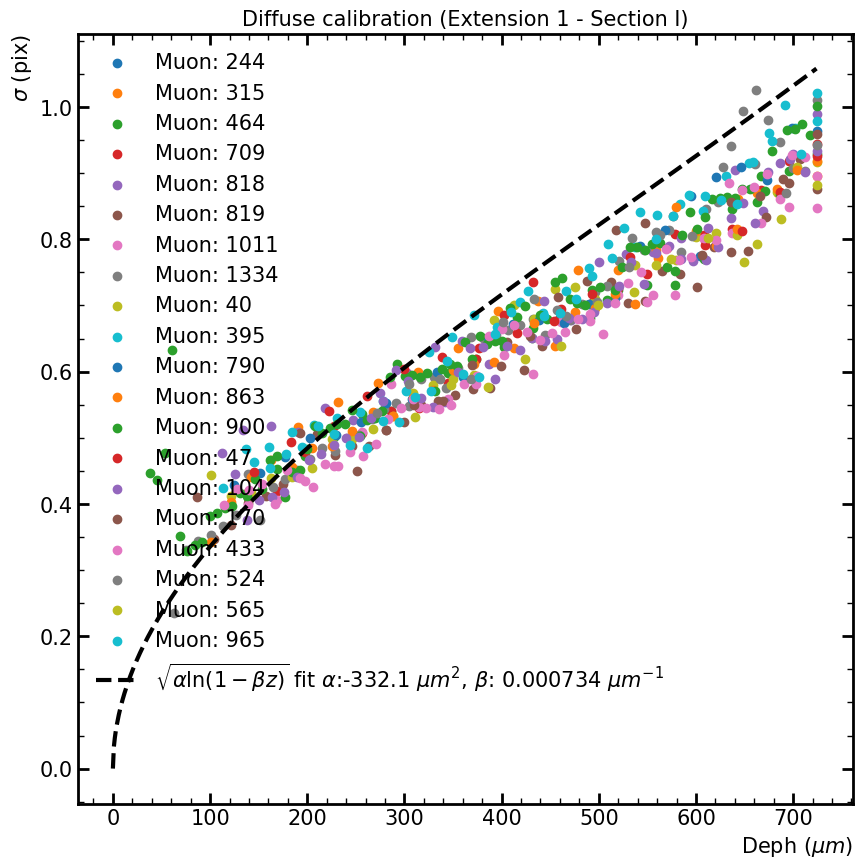

Warning in <TROOT::Append>: Replacing existing TH1: histogram (Potential memory leak).


In [43]:
CCD_depth = 725 # micras
Delta_inicial = 5    # px
Delta_final = 9     # px
Bins = 50

extension = 2
img_sigma = 0.0008  # KeV 
# print(img_sigma)
fig, axs_all = plt.subplots(figsize = [10,10])


# DAta for 0 to 5 
#  [37, 157, 244, 315, 391, 464, 513, 622, 632, 635, 636, 709, 727, 818, 819, 847, 1011, 1221, 1245, 1252, 1334]

#  Data for 355 to 360
# [17, 29, 40, 113, 203, 258, 327, 344, 376, 395, 403, 790, 802, 833, 863, 890, 900, 975, 999, 1028, 1047, 1056, 1066, 1090, 1151, 1180, 1316]

# Data for 355 to 360
# 5, 43, 47, 50, 81, 96, 104, 170, 192, 209, 219, 228, 238, 241, 246, 252, 265, 285, 313, 347, 372, 379, 388, 399, 411, 433, 442, 524, 565, 568, 
# 591, 701, 723, 766, 768, 785, 786, 821, 835, 838, 839, 841, 846, 859, 860, 879, 889, 899, 909, 921, 945, 957, 965, 986, 997, 1016, 1043, 1069, 
# 1073, 1080, 1086, 1116, 1131, 1137, 1153, 1154, 1157, 1206, 1225, 1247, 1248, 1330]

# 47, 104, 170, 209, 219, 241, 246, 252,372, 433, 524, 565, 839, 859, 921, 965, 1131, 1206, 1225 
list_muonlabels0 = [244, 315, 464,709, 818,819, 1011, 1334] # Phi 0 to 5 deg
list_muonlabels1= [40, 395, 790, 863, 900] # Phi 355 to 360
list_muonlabels2= [47, 104, 170, 433, 524, 565, 965] # Phi 175 to 185

# print(list_muonlabels0 +  list_muonlabels1)
list_muonlabels = list_muonlabels0  +  list_muonlabels1  +  list_muonlabels2 
# list_muonlabels = list_muonlabels0  +  list_muonlabels1 
# list_muonlabels = list_muonlabels2


for label_muon in list_muonlabels: 
    event = list_datamask[label_muon]
    size_x = event.shape[1]
    size_y = event.shape[0]

    # lines = 0
    Longitud_XY = size_x 
    Z_inicial = (Delta_inicial * CCD_depth) / (Longitud_XY - Delta_final)
    # print('Muon: ', label_muon, ', Shape (X, Y): ', event.shape[1], event.shape[0])

    list_fitsigmas = []
    if label_muon in list_muonlabels2:
        Delta_inicial = Delta_final
        Delta_final = Delta_inicial


    for lable_line in range(Delta_inicial, size_x - Delta_final):
        # print(label_line)
        line = event[:, lable_line: lable_line + 1]
        Carga_renglon = line.sum()
        Mean_carga = np.mean(line)
        Longitud_linea = len(line)

        Mean_in  = 0
        var = 0
        carga_cuadrada = 0

        ### Se calcula el X promedio ##
        for pixel in range(0, Longitud_linea):
            if line[pixel][0]:
                element_pixel = (pixel * line[pixel][0]) / Carga_renglon
                Mean_in = Mean_in + element_pixel
            else:
                element_pixel = 0
            
            Mean_in = Mean_in + element_pixel

        ## Calcula la suma de las cargas al cuadrado ##
        for pixel in range(0, Longitud_linea, 1):
            if line[pixel][0]:
                element_pixel = line[pixel][0]**2
            else:
                element_pixel = 0

            carga_cuadrada = carga_cuadrada + element_pixel 

        Mean_carga_cuadrada = carga_cuadrada/Longitud_linea

        ### Se calcula la varianza ##
        for pixel in range(0, Longitud_linea, 1):
            if line[pixel][0]:
                element_pixel =(1 / (Longitud_linea - 1)) * (pixel - Mean_in)**2 * line[pixel][0]
                # element_pixel =(1 / (Longitud_linea - 1)) * (pixel - Mean_in)**2
                var = var + element_pixel  ### COreggir la varianza con otro estimados

        ### Se corrige la varianza con la carga ###
        var_true = var * (Mean_carga_cuadrada / (Mean_carga**2))
        # var_true = var / Carga_renglon

        ### Se calcula la sigma ###
        sigma_in = np.sqrt(var_true)
        # print(sigma_in)
        # sigma_in = np.sqrt(var_true)


        ##Se crea un arreglo para usarlo en el plot de los datos, y se realiza el juste ##
        list_xlabel = np.arange(0.5, len(line), 1)


        ## Ajuste gaussiano con ROOT ##
        fgaus2 = TF1("fgauss","gaus",  0,  len(line), 3) # TF1("nombre", "funcion escrita como en root", min, max, #parametros)
        h3=TH1F("histogram", "Distribution of Line", len(line) + 1, 0,  len(line) )

        for index in range(0, len(line)):
            if line[index][0] != 0:
                # print(index, line[index])
                h3.SetBinContent( index + 1, line[index][0])
                h3.SetBinError(index + 1, img_sigma)
                # h3.SetBinError(index + 1, 0.001)
                #print(pixel_value)

        fgaus2.SetParameters(np.max(line),Mean_in,sigma_in) # Establecer parametros iniciales del fit, de manera visual es posible determinarlos como una primera aproximacion
        h3.Fit(fgaus2, "RQN")

        fit_const = fgaus2.GetParameters()[0]
        fit_mean = fgaus2.GetParameters()[1]
        fit_sigma = fgaus2.GetParameters()[2]


        # fit_sigma = sigma_in
        # print('Sigma fit: ', fit_sigma)
        list_fitsigmas.append(fit_sigma)

        del h3

    list_deep = []
    list_xlabel_sigmas = np.linspace(Z_inicial, CCD_depth, len(list_fitsigmas))
    for deep in list_xlabel_sigmas:
        list_deep.append(deep)

    if label_muon in list_muonlabels2:
        list_fitsigmas.reverse()

    axs_all.scatter(list_deep, list_fitsigmas, label = 'Muon: ' + str(label_muon))
    # axs_all.scatter(list_deep, list_fitsigmas)


def diffution_curve(z, alpha, beta):
    return np.sqrt((alpha * np.log(1 - (beta * z))))

fit_range = np.arange(0, 725)
# fit_alpha, fit_beta = -348.2, 0.000702
Label = r'$\sqrt{\alpha \ln(1 - \beta z)}$ fit $\alpha$:' + str(np.around(fit_alpha, 1)) + r' $\mu m^{2}$, $\beta$: ' + str(np.around(fit_beta, 6)) + r' $\mu m^{-1}$'

# axs_all.plot(fit_range, diffution_curve(fit_range, alpha=-200, beta=0.001) / 15, '--r', linewidth = 3)
axs_all.plot(fit_range, diffution_curve(fit_range, alpha=fit_alpha, beta=fit_beta)/15, '--k', linewidth = 3, label= Label)
# axs_all.plot(fit_range, diffution_curve(fit_range, alpha=-292.4325743170209, beta=3.990904646095944e-06), '--c', linewidth = 2, label='Fit CONNIE')

axs_all.set_title('Diffuse calibration (Extension 1 - Section I)', size = 15)#, y=0.92)}
axs_all.set_ylabel(r'$\sigma$ (pix)')
axs_all.set_xlabel(r'Deph ($\mu m$)')
# axs_all.set_ylim(0, )
# axs_all.set_xlim(0, 725)
axs_all.legend()
axs_all.grid
plt.show()

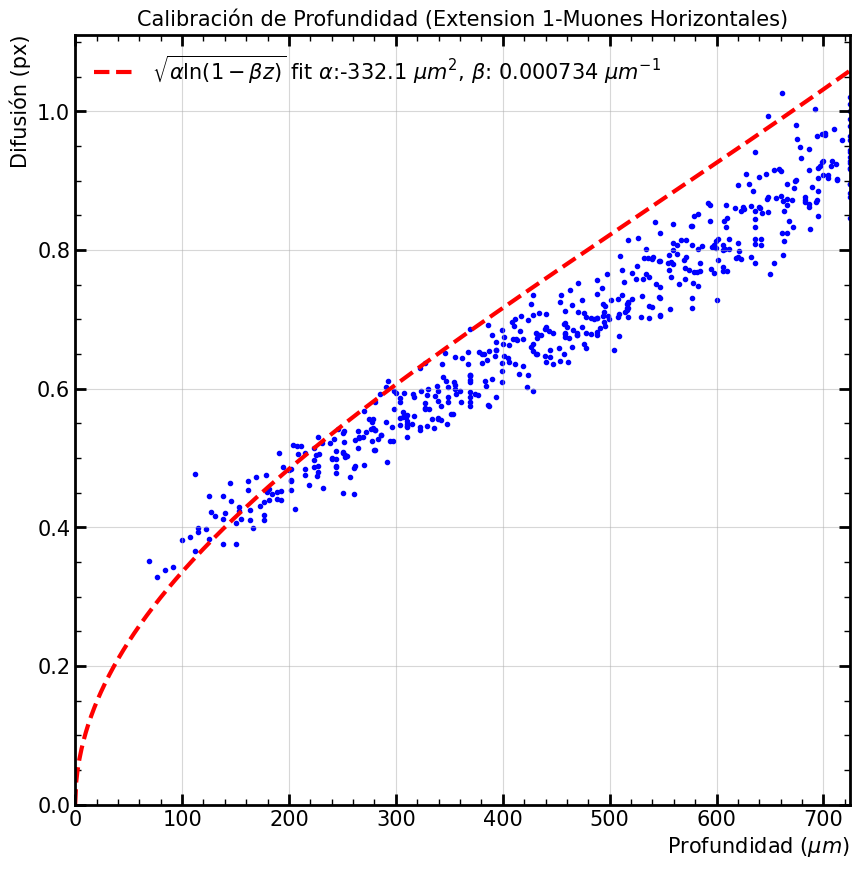

In [44]:
img_sigma = 0.0008  # KeV 
# print(img_sigma)
fig, axs_all = plt.subplots(figsize = [10,10])

# list_muonlabels = [256, 257, 258]

list_all_sigmas = []
list_all_deeps = []

for label_muon in list_muonlabels: 
    event = list_datamask[label_muon]
    size_x = event.shape[1]
    size_y = event.shape[0]

    # lines = 0
    Longitud_XY = size_x
    Z_inicial = (Delta_inicial * CCD_depth) / (Longitud_XY - Delta_final)
    # print('Muon: ', label_muon, ', Shape (X, Y): ', event.shape[1], event.shape[0])

    list_fitsigmas = []
    if label_muon in list_muonlabels2:
        Delta_inicial = Delta_final
        Delta_final = Delta_inicial

    for lable_line in range(Delta_inicial, size_x - Delta_final):
        line = event[:, lable_line: lable_line + 1]
        Carga_renglon = line.sum()
        Mean_carga = np.mean(line)
        Longitud_linea = len(line)


        Mean_in  = 0
        var = 0
        carga_cuadrada = 0

        ### Se calcula el X promedio ##
        for pixel in range(0, Longitud_linea):
            if line[pixel][0]:
                element_pixel = (pixel * line[pixel][0]) / Carga_renglon
                Mean_in = Mean_in + element_pixel
            else:
                element_pixel = 0
            
            Mean_in = Mean_in + element_pixel

        ## Calcula la suma de las cargas al cuadrado ##
        for pixel in range(0, Longitud_linea, 1):
            if line[pixel][0]:
                element_pixel = line[pixel][0]**2
            else:
                element_pixel = 0

            carga_cuadrada = carga_cuadrada + element_pixel 

        Mean_carga_cuadrada = carga_cuadrada/Longitud_linea

        ### Se calcula la varianza ##
        for pixel in range(0, Longitud_linea, 1):
            if line[pixel][0]:
                element_pixel =(1 / (Longitud_linea - 1)) * (pixel - Mean_in)**2 * line[pixel][0]
                var = var + element_pixel  ### COreggir la varianza con otro estimados

        ### Se corrige la varianza con la carga ###
        # var_true = var * (Mean_carga_cuadrada / (Mean_carga**2))
        var_true = var / Carga_renglon

        ### Se calcula la sigma ###
        sigma_in = np.sqrt(var)
        # print(sigma_in)
        # sigma_in = np.sqrt(var_true)


        ##Se crea un arreglo para usarlo en el plot de los datos, y se realiza el juste ##
        list_xlabel = np.arange(0.5, len(line), 1)


        ## Ajuste gaussiano con ROOT ##
        fgaus2 = TF1("fgauss","gaus",  0,  len(line), 3) # TF1("nombre", "funcion escrita como en root", min, max, #parametros)
        h3=TH1F("histogram", "Distribution of Line", len(line) + 1, 0,  len(line) )

        for index in range(0, len(line)):
            if line[index][0] != 0:
                # print(index, line[index])
                h3.SetBinContent( index + 1, line[index][0])
                h3.SetBinError(index + 1, img_sigma)
                # h3.SetBinError(index + 1, 0.001)
                #print(pixel_value)

        fgaus2.SetParameters(np.max(line),Mean_in,sigma_in) # Establecer parametros iniciales del fit, de manera visual es posible determinarlos como una primera aproximacion
        h3.Fit(fgaus2, "RQN")

        fit_const = fgaus2.GetParameters()[0]
        fit_mean = fgaus2.GetParameters()[1]
        fit_sigma = fgaus2.GetParameters()[2]


        # fit_sigma = sigma_in
        # print('Sigma fit: ', fit_sigma)
        list_fitsigmas.append(fit_sigma)

        del h3

    list_deep = []
    list_xlabel_sigmas = np.linspace(Z_inicial, CCD_depth, len(list_fitsigmas))
    for deep in list_xlabel_sigmas:
        list_deep.append(deep)

    # if label_muon in (143, 302, 321, 362, 383, 385, 404, 434, 550, 793, 864, 929, 1090, 1091):
    #     # print('Gola', list_fitsigmas[0], list_fitsigmas[-1])
    #     list_fitsigmas.reverse()
    #     # print('Agios', list_fitsigmas[0], list_fitsigmas[-1], end='\n\n')
    if label_muon in list_muonlabels2:
        list_fitsigmas.reverse()
        
    for index in range(0, len(list_fitsigmas)):
        list_all_sigmas.append(list_fitsigmas[index])
        list_all_deeps.append(list_deep[index])

    # axs_all.scatter(list_deep, list_fitsigmas, marker='2', label = 'Muon: ' + str(label_muon))
del list_fitsigmas
del list_deep


fit_range = np.arange(0, 725)

axs_all.scatter(list_all_deeps, list_all_sigmas, marker='.', facecolor = 'b')

def diffution_curve(x, alpha, beta):
    return np.sqrt((alpha * np.log(1 - (beta * x))))

# popt_DM, _ = curve_fit(diffution_curve, list_all_deeps, list_all_sigmas, maxfev=100000, p0= [1, 1])
# dict_diffution_model = {'Alpha' : popt_DM[0], 'Beta' : popt_DM[1]}
# print('Alpha: ', dict_diffution_model['Alpha'], ' Beta: ', dict_diffution_model['Beta'])



axs_all.plot(fit_range, diffution_curve(fit_range, alpha=fit_alpha, beta=fit_beta)/15, '--r', linewidth = 3, label= Label)
# axs_all.plot(fit_range, diffution_curve(fit_range, -611, 0.00045)/15, '--r', linewidth = 3)

axs_all.set_title('Calibración de Profundidad (Extension 1-Muones Horizontales)', size = 15)#, y=0.92)}
axs_all.set_ylabel(r'Difusión (px)')
axs_all.set_xlabel(r'Profundidad ($\mu m$)')
axs_all.set_ylim(0,)
axs_all.set_xlim(0, 725)
axs_all.legend()
axs_all.grid()
plt.show()

In [45]:
list_all_sigmas = []
list_all_deeps = []

for label_muon in list_muonlabels: 
    event = list_datamask[label_muon]
    size_x = event.shape[1]
    size_y = event.shape[0]

    # lines = 0
    Longitud_XY = size_x
    Z_inicial = (Delta_inicial * CCD_depth) / (Longitud_XY - Delta_final)
    # print('Muon: ', label_muon, ', Shape (X, Y): ', event.shape[1], event.shape[0])

    list_fitsigmas = []
    if label_muon in list_muonlabels2:
        Delta_inicial = Delta_final
        Delta_final = Delta_inicial

    for lable_line in range(Delta_inicial, size_x - Delta_final):
        line = event[:, lable_line: lable_line + 1]
        Carga_renglon = line.sum()
        Mean_carga = np.mean(line)
        Longitud_linea = len(line)


        Mean_in  = 0
        var = 0
        carga_cuadrada = 0

        ### Se calcula el X promedio ##
        for pixel in range(0, Longitud_linea):
            if line[pixel][0]:
                element_pixel = (pixel * line[pixel][0]) / Carga_renglon
                Mean_in = Mean_in + element_pixel
            else:
                element_pixel = 0
            
            Mean_in = Mean_in + element_pixel

        ## Calcula la suma de las cargas al cuadrado ##
        for pixel in range(0, Longitud_linea, 1):
            if line[pixel][0]:
                element_pixel = line[pixel][0]**2
            else:
                element_pixel = 0

            carga_cuadrada = carga_cuadrada + element_pixel 

        Mean_carga_cuadrada = carga_cuadrada/Longitud_linea

        ### Se calcula la varianza ##
        for pixel in range(0, Longitud_linea, 1):
            if line[pixel][0]:
                element_pixel =(1 / (Longitud_linea - 1)) * (pixel - Mean_in)**2 * line[pixel][0]
                var = var + element_pixel  ### COreggir la varianza con otro estimados

        ### Se corrige la varianza con la carga ###
        # var_true = var * (Mean_carga_cuadrada / (Mean_carga**2))
        var_true = var / Carga_renglon

        ### Se calcula la sigma ###
        sigma_in = np.sqrt(var)
        # print(sigma_in)
        # sigma_in = np.sqrt(var_true)


        ##Se crea un arreglo para usarlo en el plot de los datos, y se realiza el juste ##
        list_xlabel = np.arange(0.5, len(line), 1)


        ## Ajuste gaussiano con ROOT ##
        fgaus2 = TF1("fgauss","gaus",  0,  len(line), 3) # TF1("nombre", "funcion escrita como en root", min, max, #parametros)
        h3=TH1F("histogram", "Distribution of Line", len(line) + 1, 0,  len(line) )

        for index in range(0, len(line)):
            if line[index][0] != 0:
                # print(index, line[index])
                h3.SetBinContent( index + 1, line[index][0])
                h3.SetBinError(index + 1, img_sigma)
                # h3.SetBinError(index + 1, 0.001)
                #print(pixel_value)

        fgaus2.SetParameters(np.max(line),Mean_in,sigma_in) # Establecer parametros iniciales del fit, de manera visual es posible determinarlos como una primera aproximacion
        h3.Fit(fgaus2, "RQN")

        fit_const = fgaus2.GetParameters()[0]
        fit_mean = fgaus2.GetParameters()[1]
        fit_sigma = fgaus2.GetParameters()[2]


        # fit_sigma = sigma_in
        # print('Sigma fit: ', fit_sigma)
        list_fitsigmas.append(fit_sigma)

        del h3

    list_deep = []
    list_xlabel_sigmas = np.linspace(Z_inicial, CCD_depth, len(list_fitsigmas))
    for deep in list_xlabel_sigmas:
        list_deep.append(deep)

    if label_muon in list_muonlabels2:
        list_fitsigmas.reverse()

    for index in range(0, len(list_fitsigmas)):
        list_all_sigmas.append(list_fitsigmas[index])
        list_all_deeps.append(list_deep[index])

    # axs_all.scatter(list_deep, list_fitsigmas, marker='2', label = 'Muon: ' + str(label_muon))
del list_fitsigmas
del list_deep



# fit_range = np.arange(0, 900)
# axs_all.scatter(list_all_deeps, list_all_sigmas, marker='2')
 
h_model = TGraph(len(list_all_sigmas), np.array(list_all_deeps),np.array(list_all_sigmas))
h_model.SetMarkerStyle(2) # Set marker style (e.g., solid circle)
h_model.SetTitle("Modelo de dif. (Extensión 2 - Muones Horizontales)")
h_model.GetXaxis().SetTitle("Profundidad (micras)")
h_model.GetYaxis().SetTitle("Anchura (micras)")
h_model.SetStats()
h_model.GetXaxis().SetRangeUser(0, 725)
h_model.GetYaxis().SetRangeUser(0, 1.2)



Range_fit = [0, 725]
diff_curve = TF1("diff_curve", "sqrt(([0] * log(1 - [1]*x)))/15", Range_fit[0], Range_fit[1], 2) #np.sqrt(np.abs(alpha * np.log(1 - (beta * z))))

diff_curve.SetParameters(-200, 0.00001) # Establecer parametros iniciales del fit, de manera visual es posible determinarlos como una primera aproximacion
h_model.Fit(diff_curve, "RNQ")

fit_alpha = diff_curve.GetParameters()[0]
fit_beta = diff_curve.GetParameters()[1]
chi2 = diff_curve.GetChisquare()
ndf = diff_curve.GetNDF()
prob = diff_curve.GetProb()

fit_alpha_err = diff_curve.GetParErrors()[0]
fit_beta_err = diff_curve.GetParErrors()[1]

print('Alpha: ', fit_alpha, '+- ', fit_alpha_err) 
print('Beta: ', fit_beta,  '+- ', fit_beta_err)
print('Chi2/ndf: ', chi2, '/', ndf)
print('Prob: ', prob)




c3=TCanvas("","", 1000, 600)
h_model.Draw("AP same")
diff_curve.Draw("same")
c3.Draw()

leg = TLegend(0.1,0.7,0.48,0.9)
leg.AddEntry(diff_curve, r"\sqrt{\alpha \log(1 - \beta z)} fit: \alpha= " + str(np.around(fit_alpha, 3)) + r" \mu m^2, \beta= " + str(np.around(fit_beta, 6)) + " \mu m^{-1}", "L")
leg.Draw()


Alpha:  -492.3436562231453 +-  56.04493196451444
Beta:  0.0004402028680291546 +-  4.372938876385827e-05
Chi2/ndf:  0.7925180397002676 / 535
Prob:  1.0


In [46]:
from array import array

spread_array = array('f', [-9999])
deep_array = array('f', [-9999])

location_file = './'
file_root_name = 'tree_DiffusionMod_Ext2_Horz.root'
file = TFile.Open(location_file  + file_root_name, "RECREATE")
tree = TTree('tree', 'tree')

tree.Branch('sprd', spread_array, 'sprd/F')
tree.Branch('deep', deep_array, 'deep/F')

for i in range(0, len(list_all_sigmas)):
    spread_array[0] = list_all_sigmas[i]
    deep_array[0] = list_all_deeps[i]
    
    tree.Fill()

tree.Write()
file.Close()

### Ajustes horizontal y vertical

In [238]:
Range_fit = [0, 725]
diff_curve_1 = TF1("diff_curve_1", "sqrt(([0] * log(1 - [1]*x)))/15", Range_fit[0], Range_fit[1], 2)
diff_curve_1.SetParameters(-492.344, 0.00044)
diff_curve_1.SetLineColor(2)
diff_curve_1.SetTitle("Modelo de Difusión (Ext 2)")
diff_curve_1.GetXaxis().SetTitle("Profundidad (micras)")
diff_curve_1.GetYaxis().SetTitle("Anchura (px)")
diff_curve_1.GetYaxis().SetRangeUser(0, 1.6)

diff_curve_2 = TF1("diff_curve_2", "sqrt(([0] * log(1 - [1]*x)))/15", Range_fit[0], Range_fit[1], 2)
diff_curve_2.SetParameters(-332.053, 0.000734)
diff_curve_2.SetLineColor(4)
diff_curve_2.GetYaxis().SetRangeUser(0, 1.6)

c3=TCanvas("","", 1000, 600)
diff_curve_1.Draw()
diff_curve_2.Draw("same")

leg = TLegend(0.1,0.7,0.48,0.9)
leg.AddEntry(diff_curve_1, "Muones Horizontales", "L")
leg.AddEntry(diff_curve_2, "Muones Verticales", "L")
leg.Draw()

c3.Draw()

# Extensiones juntas

In [239]:
### ====== Extension 1 ===== ###
Range_fit = [0, 725]
diff_curve_1 = TF1("diff_curve_1", "sqrt(([0] * log(1 - [1]*x)))/15", Range_fit[0], Range_fit[1], 2)
diff_curve_1.SetParameters(-804.301, 0.000339)
diff_curve_1.SetLineColor(1)
diff_curve_1.SetTitle("Modelo de Difusión (Ext 1 y 2)")
diff_curve_1.GetXaxis().SetTitle("Profundidad (micras)")
diff_curve_1.GetYaxis().SetTitle("Anchura (px)")

diff_curve_2 = TF1("diff_curve_2", "sqrt(([0] * log(1 - [1]*x)))/15", Range_fit[0], Range_fit[1], 2)
diff_curve_2.SetParameters(-2400.842, 0.000126)
diff_curve_2.SetLineColor(2)

### ===== Extension 2 ===== ###
diff_curve_3 = TF1("diff_curve_3", "sqrt(([0] * log(1 - [1]*x)))/15", Range_fit[0], Range_fit[1], 2)
diff_curve_3.SetParameters(-492.344, 0.00044)
diff_curve_3.SetLineColor(3)

diff_curve_4 = TF1("diff_curve_4", "sqrt(([0] * log(1 - [1]*x)))/15", Range_fit[0], Range_fit[1], 2)
diff_curve_4.SetParameters(-332.053, 0.000734)
diff_curve_4.SetLineColor(4)
diff_curve_4.GetYaxis().SetRangeUser(0, 1.6)


c3=TCanvas("","", 1000, 600)
diff_curve_1.Draw()
diff_curve_2.Draw("same")
diff_curve_3.Draw("same")
diff_curve_4.Draw("same")

leg = TLegend(0.1,0.7,0.48,0.9)
leg.AddEntry(diff_curve_1, "Muones Horizontales (Ext1)", "L")
leg.AddEntry(diff_curve_2, "Muones Verticales (Ext1)", "L")
leg.AddEntry(diff_curve_3, "Muones Horizontales (Ext2)", "L")
leg.AddEntry(diff_curve_4, "Muones Verticales (Ext2)", "L")
leg.Draw()

c3.Draw()




### Verticales y Horizontales